In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
from yellowbrick.cluster import KElbowVisualizer
import matplotlib.pyplot as plt
import pandas as pd 
import seaborn as sns
from sklearn.cluster import KMeans
from sksurv.base import SurvivalAnalysisMixin as s
from sklearn.model_selection import train_test_split, RandomizedSearchCV, cross_val_score
from sksurv.preprocessing import encode_categorical
 
from sksurv.functions import StepFunction
from sksurv.linear_model import CoxPHSurvivalAnalysis, CoxnetSurvivalAnalysis
from sksurv.ensemble import (ComponentwiseGradientBoostingSurvivalAnalysis, 
                            RandomSurvivalForest, 
                            ExtraSurvivalTrees, 
                            GradientBoostingSurvivalAnalysis, 
                            ExtraSurvivalTrees)
from sksurv.meta import EnsembleSelection, EnsembleSelectionRegressor
from sksurv.metrics import integrated_brier_score
from matplotlib.colors import ListedColormap
from mlxtend.evaluate import paired_ttest_5x2cv
from mlxtend.evaluate import combined_ftest_5x2cv
from lifelines import KaplanMeierFitter
from scipy.cluster import hierarchy
from lifelines.statistics import logrank_test, multivariate_logrank_test, pairwise_logrank_test
from sklearn import preprocessing
from sklearn.model_selection import StratifiedKFold, KFold
from lifelines.plotting import add_at_risk_counts
import scipy.stats
import sklearn
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import optuna
from sklearn.model_selection import cross_val_score
from sksurv.metrics import integrated_brier_score
from lifelines import CoxPHFitter
from lifelines.statistics import proportional_hazard_test
import scipy.stats as stats
from statsmodels.stats.outliers_influence import variance_inflation_factor 
from sklearn.preprocessing import StandardScaler
from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = 'all'

In [2]:
# OUS: Train data
OUS_D1 = pd.read_csv('OUS_D1.csv')
OUS_D2 = pd.read_csv('OUS_D2.csv')
OUS_D3 = pd.read_csv('OUS_D3.csv')
OUS_DFS_target = pd.read_csv('OUS_DFS_target.csv')
OUS_OS_target = pd.read_csv('OUS_OS_target.csv')
response_OUS = pd.read_csv('response_ous.csv', sep=';')

# MAASTRO: Test data 
MAASTRO_D1 = pd.read_csv('MAASTRO_D1.csv')
MAASTRO_D2 = pd.read_csv('MAASTRO_D2.csv')
MAASTRO_D3 = pd.read_csv('MAASTRO_D3.csv')
MAASTRO_DFS_target = pd.read_csv('MAASTRO_DFS_target.csv')
MAASTRO_OS_target = pd.read_csv('MAASTRO_OS_target.csv')
response_MAASTRO = pd.read_csv('maastro_response_full.csv', sep=',')

In [3]:
# Need to choose patient_id from OUS_D1 in response_OUS
data = list(OUS_D1['patient_id'])
mask = response_OUS['patient_id'].isin(data)
response_OUS = response_OUS[mask] 
response_OUS.head(10)

# Merge OUS_D1 with response_OUS
clinical_train = pd.merge(OUS_D1, response_OUS, on='patient_id', how='inner')
clinical_train = clinical_train.loc[:, ~clinical_train.columns.isin(['DFS', 'event_DFS', 'LRC', 'event_LRC'])]
clinical_train

,patient_id,OS,event_OS,DFS,event_DFS,LRC,event_LRC
2,5,114.312329,0,32.909589,0,32.909589,0
5,11,111.846575,0,27.715068,0,27.715068,0
6,12,49.479452,1,43.101370,1,49.479452,0
9,15,17.589041,1,17.589041,1,17.589041,0
10,16,66.739726,1,47.473973,1,47.473973,0
14,23,21.106849,1,10.126027,1,10.126027,1
15,24,87.978082,1,87.978082,1,87.978082,0
17,26,62.005479,1,53.983562,1,62.005479,0
18,27,105.073973,0,98.005479,0,98.005479,0
21,31,20.613699,1,3.419178,1,3.419178,1


,patient_id,age,female,cavum_oris,oropharynx,hypopharynx,larynx,histgrade_high,hpv_related,charlson,pack_years,uicc8_III-IV,SUVpeak,MTV,TLG,OS,event_OS
0,5,54.238356,1,0,1,0,0,1,0.0,0,0.000000,0.0,14.473272,7.934,86.228420,114.312329,0
1,11,54.539726,0,0,0,0,1,0,0.0,1,27.404795,0.0,5.044678,1.656,7.040100,111.846575,0
2,12,59.019178,0,1,0,0,0,1,0.0,1,41.019178,1.0,7.839043,14.502,83.569669,49.479452,1
3,15,70.726027,0,0,0,0,1,0,0.0,1,37.500000,0.0,2.880631,2.440,5.567091,17.589041,1
4,16,67.865753,0,0,0,0,1,0,0.0,1,53.000000,0.0,5.402006,3.668,16.150550,66.739726,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
134,249,60.435616,0,0,1,0,0,1,1.0,0,0.000000,0.0,9.290139,3.650,26.280140,42.805479,0
135,250,68.794521,0,0,1,0,0,1,1.0,0,0.000000,1.0,7.172883,18.967,101.754834,42.739726,0
136,252,57.498630,0,0,1,0,0,1,1.0,1,39.498630,0.0,13.873187,6.370,66.273201,42.312329,0
137,253,65.684932,0,0,1,0,0,1,1.0,1,71.527397,1.0,7.507419,12.443,71.832443,42.246575,0


In [4]:
# Drop patient_id column
clinical_train = clinical_train.drop('patient_id', axis=1)

In [5]:
# Check null values in D2 
clinical_train.isnull().sum().sum()

0

## Test dataset: MAASTRO 

In [6]:
(MAASTRO_D1['patient_id'] == MAASTRO_OS_target['patient_id']).sum()

99

In [7]:
# Rename the column name of response_MAASTRO 
response_MAASTRO.rename(columns = {'Index' : 'patient_id'}, inplace = True)

In [8]:
# need to choose patient_id from MAASTRO_D1 in response_MAASTRO
data = list(MAASTRO_D1['patient_id'])
mask = response_MAASTRO['patient_id'].isin(data)
response_MAASTRO = response_MAASTRO[mask] 
response_MAASTRO

,patient_id,OS,OS_event,LRC,LRC_event,DFS,DFS_event
0,1,62.43,0.0,62.43,0.0,62.43,0.0
1,2,60.00,0.0,60.00,0.0,60.00,0.0
2,3,44.43,1.0,8.83,1.0,8.83,1.0
3,4,37.20,1.0,19.37,0.0,19.73,1.0
5,6,59.23,0.0,59.23,0.0,59.23,0.0
...,...,...,...,...,...,...,...
109,110,19.00,1.0,13.27,1.0,13.27,1.0
110,111,85.87,1.0,82.83,0.0,85.87,1.0
111,112,42.87,0.0,42.87,0.0,42.87,0.0
112,113,58.93,0.0,58.93,0.0,58.93,0.0


In [9]:
# Merge MAASTRO_D1 with response_MAASTRO
clinical_test = pd.merge(MAASTRO_D1, response_MAASTRO, on='patient_id', how='inner')
clinical_test = clinical_test.loc[:, ~clinical_test.columns.isin(['DFS', 'DFS_event', 'LRC', 'LRC_event'])]
clinical_test

,patient_id,age,female,cavum_oris,oropharynx,hypopharynx,larynx,histgrade_high,hpv_related,charlson,pack_years,uicc8_III-IV,SUVpeak,MTV,TLG,OS,OS_event
0,1,55,0,0,1,0,0,1,1,1,0,0,15.438583,22.841,263.611623,62.43,0.0
1,2,55,0,0,1,0,0,0,0,0,20,1,8.829353,5.660,36.980700,60.00,0.0
2,3,55,0,0,1,0,0,0,0,1,6,1,13.476123,7.791,74.636342,44.43,1.0
3,4,61,1,0,0,0,1,1,0,1,45,1,8.632732,7.908,46.791979,37.20,1.0
4,6,70,0,0,1,0,0,1,1,1,59,0,9.783954,15.237,107.637514,59.23,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
94,110,66,1,0,0,0,1,0,0,0,55,1,31.338410,6.110,144.490782,19.00,1.0
95,111,63,0,0,0,0,1,0,0,1,174,1,13.041604,7.182,69.214868,85.87,1.0
96,112,63,0,0,1,0,0,1,1,1,0,1,8.944517,16.483,102.594274,42.87,0.0
97,113,54,0,0,1,0,0,1,1,0,0,0,14.184236,9.981,103.229492,58.93,0.0


In [10]:
# Drop patient_id column
clinical_test = clinical_test.drop('patient_id', axis=1)

In [11]:
# Some rows have null values in OS, OS_event -> Remove those rows
clinical_test[clinical_test.isnull().any(axis=1)]
clinical_test = clinical_test.dropna(how='any',axis=0) 

,age,female,cavum_oris,oropharynx,hypopharynx,larynx,histgrade_high,hpv_related,charlson,pack_years,uicc8_III-IV,SUVpeak,MTV,TLG,OS,OS_event


In [12]:
# X
X = clinical_train.loc[:, ~clinical_train.columns.isin(['OS', 'event_OS'])]

# y 
y = clinical_train.loc[:, ['OS', 'event_OS']]

In [13]:
# Set lower, upper time point and times for IBS calculation later 
lower, upper = np.percentile(y['OS'], [10, 90])
times = np.arange(lower, upper)

# y into array 
lists = [] 
for i, j in zip(y['event_OS'], y['OS']): 
    lists.append((i, j))

y = np.array(lists, dtype=[('status', bool), ('time', np.int32)])

In [14]:
# Shape
print('X_train: ', X.shape)
print('y_train: ', y.shape)

X_train:  (139, 14)
y_train:  (139,)


In [15]:
clinical_test.rename(columns = {'OS_event' : 'event_OS'}, inplace = True)

In [16]:
# X
X_MAASTRO = clinical_test.loc[:, ~clinical_test.columns.isin(['OS', 'event_OS'])]

# y y_MAASTRO
y_MAASTRO = clinical_test.loc[:, ['OS', 'event_OS']]
lower, upper = np.percentile(y_MAASTRO['OS'], [10, 90])
times = np.arange(lower, upper)

# y into array 
lists = [] 
for i, j in zip(y_MAASTRO['event_OS'], y_MAASTRO['OS']): 
    lists.append((i, j))

y_MAASTRO = np.array(lists, dtype=[('status', bool), ('time', np.int32)])

clinical_test.shape

(99, 16)

## Standardization for Clustering

In [17]:
original_X = X.copy()

In [18]:
# Standardize the data 
## Save the column and index 
X_columns = X.columns 
X_index = X.index

## Standardize the data but not the categorical columns
categorical_columns = ['female', 
                        'cavum_oris',
                        'oropharynx',
                        'hypopharynx',
                        'larynx',
                        'histgrade_high',
                        'hpv_related',
                        'charlson',
                        'uicc8_III-IV']
### Separate the categorical and non-categorical columns
X_categorical = X[categorical_columns]
X_numeric = X.drop(categorical_columns, axis=1)
X_numeric_columns = X_numeric.columns
X_numeric_index = X_numeric.index

### Standardize non-categorical and then concat with the categorical
scaler = StandardScaler()  
X_numeric_std = StandardScaler().fit_transform(X_numeric)
X_numeric_std = pd.DataFrame(X_numeric_std, columns=X_numeric_columns, index=X_numeric_index)
X_std = pd.concat([X_categorical, X_numeric_std], axis=1)

## Sort the order of the columns as it was in the clinical train 
X_std = X_std[original_X.columns]

In [19]:
X_std

,age,female,cavum_oris,oropharynx,hypopharynx,larynx,histgrade_high,hpv_related,charlson,pack_years,uicc8_III-IV,SUVpeak,MTV,TLG
0,-0.776210,1,0,1,0,0,1,0.0,0,-1.101176,0.0,0.646616,-0.296907,-0.179158
1,-0.737256,0,0,0,0,1,0,0.0,1,0.105775,0.0,-1.098689,-0.763433,-0.587333
2,-0.158251,0,1,0,0,0,1,0.0,1,0.705374,1.0,-0.581431,0.191169,-0.192863
3,1.354953,0,0,0,0,1,0,0.0,1,0.550384,0.0,-1.499271,-0.705173,-0.594926
4,0.985240,0,0,0,0,1,0,0.0,1,1.233028,0.0,-1.032545,-0.613919,-0.540373
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
134,0.024835,0,0,1,0,0,1,1.0,0,-1.101176,0.0,-0.312822,-0.615257,-0.488161
135,1.105290,0,0,1,0,0,1,1.0,0,-1.101176,1.0,-0.704742,0.522969,-0.099128
136,-0.354794,0,0,1,0,0,1,1.0,1,0.638406,0.0,0.535536,-0.413130,-0.282017
137,0.703351,0,0,1,0,0,1,1.0,1,2.049005,1.0,-0.642817,0.038162,-0.253362


## Feature Selection

KElbowVisualizer(ax=<AxesSubplot:>, estimator=KMeans(n_clusters=9), k=(2, 10))

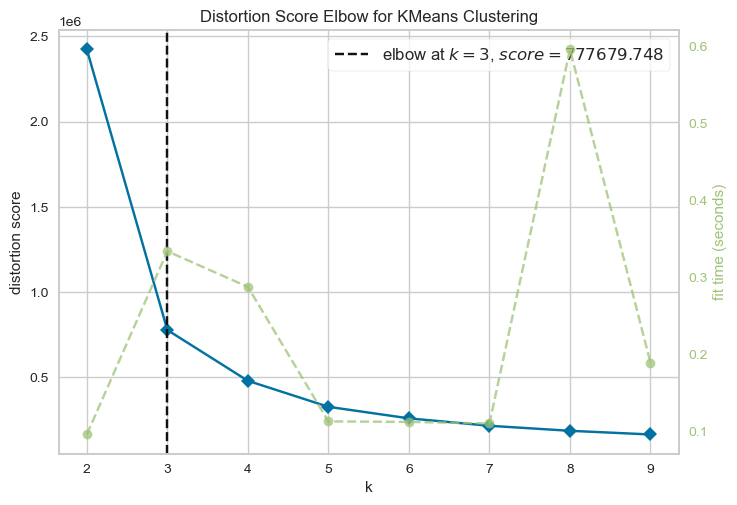

<AxesSubplot:title={'center':'Distortion Score Elbow for KMeans Clustering'}, xlabel='k', ylabel='distortion score'>

In [20]:
# Decide how many clusters to form 
X_transposed = X_std.T

kmeans = KMeans()
ssd = []
K = range(2, 10)

for k in K:
    kmeans = KMeans(n_clusters=k).fit(X_transposed)
    ssd.append(kmeans.inertia_)

kmeans = KMeans()
visu = KElbowVisualizer(kmeans, k=(2, 10))
visu.fit(clinical_train)
visu.show()

### Using the highest feature importance

In [21]:
num_clusters = 3  
kmeans = KMeans(n_clusters=num_clusters)
kmeans.fit(X_std.T)
cluster_labels = kmeans.labels_

selected_features = [] 
for i in range(3):
    coxph = CoxPHFitter(penalizer=0.00001)
    X_cluster = X_std[X_std.columns[cluster_labels==i]]
    X_cluster = pd.concat([X_cluster, clinical_train[['OS', 'event_OS']]], axis=1)
    coxph.fit(X_cluster, duration_col='OS', event_col='event_OS')

    # Get coefficients and associated feature names
    coefficients = coxph.summary['coef']
    feature_names = coxph.summary.index

    # Create a DataFrame to store coefficients and feature names
    coefficients_df = pd.DataFrame({'Feature': feature_names, 'Coefficient': coefficients})

    # Take absolute values of coefficients
    coefficients_df['Abs_Coefficient'] = coefficients_df['Coefficient'].abs()

    # Sort coefficients by absolute value to identify important features
    sorted_coefficients_df = coefficients_df.sort_values(by='Abs_Coefficient', ascending=False)

    # Display the column with the highest feature importance and its coefficient value
    max_coefficient_feature = sorted_coefficients_df.loc[sorted_coefficients_df['Abs_Coefficient'].idxmax()]
    print(f"Cluster {i}: Most important feature: {max_coefficient_feature['Feature']}, Coefficient: {max_coefficient_feature['Coefficient']}")
    selected_features.append(max_coefficient_feature['Feature'])
  

KMeans(n_clusters=3)

<lifelines.CoxPHFitter: fitted with 139 total observations, 82 right-censored observations>

Cluster 0: Most important feature: MTV, Coefficient: 0.7003896183016924


<lifelines.CoxPHFitter: fitted with 139 total observations, 82 right-censored observations>

Cluster 1: Most important feature: uicc8_III-IV, Coefficient: 1.1380539306901458


<lifelines.CoxPHFitter: fitted with 139 total observations, 82 right-censored observations>

Cluster 2: Most important feature: hpv_related, Coefficient: -1.3994025496184521


In [23]:
X_fs_fi = X.loc[:, selected_features]
X_new = X_fs_fi.copy()

X_MAASTRO_fs_fi = X_MAASTRO[selected_features]
MAASTRO_new = X_MAASTRO_fs_fi.copy()

# Standardization

In [24]:
# Standardize X_new, the new data with the selected features only 
categorical_columns = ['female', 
                        'cavum_oris',
                        'oropharynx',
                        'hypopharynx',
                        'larynx',
                        'histgrade_high',
                        'hpv_related',
                        'charlson',
                        'uicc8_III-IV']

# Set the columns_to_drop which are categorical 
columns_to_drop = [col for col in X_new.columns if col in categorical_columns]

# Drop the columns if they exist in the DataFrame and save the numeric part in X_new_numeric
X_new_categoric = X_new[columns_to_drop]
X_new_numeric = X_new.drop(columns=columns_to_drop, inplace=False)

# Do the standardization for the numeric part 
scaler = StandardScaler() 
X_new_numeric_columns = X_new_numeric.columns
X_new_numeric_index = X_new_numeric.index 
X_new_numeric_std = scaler.fit_transform(X_new_numeric)
X_new_numeric_std = pd.DataFrame(X_new_numeric_std,
                                 columns=X_new_numeric_columns, 
                                 index=X_new_numeric_index)
X_new_std = pd.concat([X_new_numeric_std, X_new_categoric], axis=1)

# Change the order of the X_new_std 
X_new_std = X_new_std[X_new.columns]

In [25]:
# Standardize X_MAASTRO 
# Set the columns_to_drop which are categorical 
columns_to_drop = [col for col in MAASTRO_new.columns if col in categorical_columns]

# Drop the columns if they exist in the DataFrame and save the numeric part in X_new_numeric
MAASTRO_new_categoric = MAASTRO_new[columns_to_drop]
MAASTRO_new_numeric = MAASTRO_new.drop(columns=columns_to_drop, inplace=False)

# Do the standardization for the numeric part 
MAASTRO_new_numeric_columns = MAASTRO_new_numeric.columns

MAASTRO_new_numeric_columns = MAASTRO_new_numeric.columns
MAASTRO_new_numeric_index = MAASTRO_new_numeric.index 
MAASTRO_new_numeric_std = scaler.transform(MAASTRO_new_numeric)
MAASTRO_new_numeric_std = pd.DataFrame(MAASTRO_new_numeric_std,
                                 columns=MAASTRO_new_numeric_columns, 
                                 index=MAASTRO_new_numeric_index)
MAASTRO_new_std = pd.concat([MAASTRO_new_numeric_std, MAASTRO_new_categoric], axis=1)

# Change the order of the X_new_std 
MAASTRO_new_std = MAASTRO_new_std[MAASTRO_new.columns]

In [26]:
X_new

,MTV,uicc8_III-IV,hpv_related
0,7.934,0.0,0.0
1,1.656,0.0,0.0
2,14.502,1.0,0.0
3,2.440,0.0,0.0
4,3.668,0.0,0.0
...,...,...,...
134,3.650,0.0,1.0
135,18.967,1.0,1.0
136,6.370,0.0,1.0
137,12.443,1.0,1.0


In [27]:
X_new_std

,MTV,uicc8_III-IV,hpv_related
0,-0.296907,0.0,0.0
1,-0.763433,0.0,0.0
2,0.191169,1.0,0.0
3,-0.705173,0.0,0.0
4,-0.613919,0.0,0.0
...,...,...,...
134,-0.615257,0.0,1.0
135,0.522969,1.0,1.0
136,-0.413130,0.0,1.0
137,0.038162,1.0,1.0


In [28]:
MAASTRO_new

,MTV,uicc8_III-IV,hpv_related
0,22.841,0,1
1,5.660,1,0
2,7.791,1,0
3,7.908,1,0
4,15.237,0,1
...,...,...,...
94,6.110,1,0
95,7.182,1,0
96,16.483,1,1
97,9.981,0,1


In [29]:
MAASTRO_new_std

,MTV,uicc8_III-IV,hpv_related
0,0.810851,0,1
1,-0.465891,1,0
2,-0.307534,1,0
3,-0.298839,1,0
4,0.245788,0,1
...,...,...,...
94,-0.432451,1,0
95,-0.352789,1,0
96,0.338380,1,1
97,-0.144792,0,1


# Modelling 

### 1. CoxPHSurvivalAnalysis

#### Train

In [30]:
# Setting the y format for skf below  
y = clinical_train[['OS', 'event_OS']]

# Running to optuna for hyperparameter tuning 
def create_objective(model_class, metric, X, y):
    def objective(trial): 
        # Create and fit survival model 
        model = model_class()
        
        scores = [] 

        skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=123)
        
        for k, (train_index, test_index) in enumerate(skf.split(X, y.iloc[:, 1])): 
            X_train, X_test = X.iloc[train_index], X.iloc[test_index]
            y_train_df, y_test_df = y.iloc[train_index], y.iloc[test_index]
            
            # y_train into array 
            y_train = [] 
            for i, j in zip(y_train_df['event_OS'], y_train_df['OS']): 
                y_train.append((i, j))
            y_train = np.array(y_train, dtype=[('status', bool), ('time', np.int32)])

            # y_test into array
            y_test = [] 
            for i, j in zip(y_test_df['event_OS'], y_test_df['OS']): 
                y_test.append((i, j))
            y_test = np.array(y_test, dtype=[('status', bool), ('time', np.int32)])

            # Standardization
            excluded_columns = ['female', 
                                'cavum_oris',
                                'oropharynx',
                                'hypopharynx',
                                'larynx',
                                'histgrade_high',
                                'hpv_related',
                                'charlson',
                                'uicc8_III-IV'
                               ]
            excluded_columns = set(excluded_columns).intersection(X.columns)

            scaler = StandardScaler() 
            X_train_included = X_train.drop(excluded_columns, axis=1)
            X_test_included = X_test.drop(excluded_columns, axis=1)
                        
            if not X_train_included.empty and not X_test_included.empty:
                X_train_included_std = scaler.fit_transform(X_train_included)
                X_test_included_std = scaler.transform(X_test_included)
                
                # Concatenation
                X_train_std_df = pd.DataFrame(X_train_included_std, columns=X_train_included.columns, index=X_train_included.index)
                X_train_std = pd.concat([X_train_std_df, X_train[excluded_columns]], axis=1)

                X_test_std_df = pd.DataFrame(X_test_included_std, columns=X_test_included.columns, index=X_test_included.index)
                X_test_std = pd.concat([X_test_std_df, X_test[excluded_columns]], axis=1)
            
            else: 
                X_train_std = X_train
                X_test_std = X_test 
            
            model.fit(X_train_std, y_train)

            if metric == "c-index":
                # Make predictions using C-index 
                c_index_score = model.score(X_test_std, y_test)
                scores.append(c_index_score)
                print(f"Fold {k + 1} C-index: {c_index_score}")
                
            elif metric == "ibs":
                # Make predictions using IBS 
                lower, upper = np.percentile(y_test["time"], [10, 90])    
                times = np.arange(lower, upper)
                cox_surv_prob = np.row_stack([fn(times) for fn in model.predict_survival_function(X_test_std)])
                ibs = integrated_brier_score(y_test, y_test, cox_surv_prob, times)
                scores.append(ibs)
                print(f"Fold {k + 1} IBS: {ibs}")
            else:
                raise ValueError("Invalid metric. Use 'C-index' or 'ibs'.")
        
        # Return the mean of scores
        return np.mean(scores)
    
    return objective

# C-index
study_cindex = optuna.create_study(direction="maximize", sampler=optuna.samplers.TPESampler(seed=123))
objective_cindex = create_objective(CoxPHSurvivalAnalysis, "c-index", X_new, y)
study_cindex.optimize(objective_cindex, n_trials=1, show_progress_bar=True)
print("\n")
print("* Best trial for C-index: \n", study_cindex.best_trial)
print("\n")
print("* Best Score for C-index: \n", study_cindex.best_value)

# Example usage for IBS
study_ibs = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=123))
objective_ibs = create_objective(CoxPHSurvivalAnalysis, "ibs", X_new, y)
study_ibs.optimize(objective_ibs, n_trials=1, show_progress_bar=True)
print("\n")
print("* Best trial for IBS: \n", study_ibs.best_trial)
print("\n")
print("* Best Score for IBS: \n", study_ibs.best_value)

[I 2024-04-13 23:47:41,302] A new study created in memory with name: no-name-3ffd2da2-50fe-4685-98ff-3faace145407


  0%|          | 0/1 [00:00<?, ?it/s]

Fold 1 C-index: 0.6753246753246753
Fold 2 C-index: 0.7544642857142857
Fold 3 C-index: 0.8137254901960784
Fold 4 C-index: 0.8227848101265823
Fold 5 C-index: 0.6525821596244131
[I 2024-04-13 23:47:42,953] Trial 0 finished with value: 0.743776284197207 and parameters: {}. Best is trial 0 with value: 0.743776284197207.


[I 2024-04-13 23:47:43,032] A new study created in memory with name: no-name-a0f20452-9203-4322-9b2c-f9a1fbfdb14b




* Best trial for C-index: 
 FrozenTrial(number=0, state=TrialState.COMPLETE, values=[0.743776284197207], datetime_start=datetime.datetime(2024, 4, 13, 23, 47, 41, 438935), datetime_complete=datetime.datetime(2024, 4, 13, 23, 47, 42, 952604), params={}, user_attrs={}, system_attrs={}, intermediate_values={}, distributions={}, trial_id=0, value=None)


* Best Score for C-index: 
 0.743776284197207


  0%|          | 0/1 [00:00<?, ?it/s]

Fold 1 IBS: 0.17596691829963726
Fold 2 IBS: 0.20513786974221754
Fold 3 IBS: 0.16460093493027642
Fold 4 IBS: 0.1410071500761203
Fold 5 IBS: 0.24271027564677294
[I 2024-04-13 23:47:43,835] Trial 0 finished with value: 0.18588462973900488 and parameters: {}. Best is trial 0 with value: 0.18588462973900488.


* Best trial for IBS: 
 FrozenTrial(number=0, state=TrialState.COMPLETE, values=[0.18588462973900488], datetime_start=datetime.datetime(2024, 4, 13, 23, 47, 43, 91418), datetime_complete=datetime.datetime(2024, 4, 13, 23, 47, 43, 835312), params={}, user_attrs={}, system_attrs={}, intermediate_values={}, distributions={}, trial_id=0, value=None)


* Best Score for IBS: 
 0.18588462973900488


In [31]:
# Setting a dictionary to save the train results 
train_cindex = {} 
train_ibs = {} 

# Saving the values to the dictionary 
train_cindex['CoxPH'] = np.round(study_cindex.best_value, 3)
train_ibs['CoxPH'] = np.round(study_ibs.best_value, 3)

In [32]:
print("train_cindex: ", np.round(study_cindex.best_value, 3))
print("train_ibs: ", np.round(study_ibs.best_value, 3))

train_cindex:  0.744
train_ibs:  0.186


#### Test

In [33]:
# y into array 
lists = [] 
for i, j in zip(y['event_OS'], y['OS']): 
    lists.append((i, j))

y = np.array(lists, dtype=[('status', bool), ('time', np.int32)])

In [34]:
# Test on MAASTRO 
cph = CoxPHSurvivalAnalysis()

cph.fit(X_new_std, y)

# Save C-index 
c_index = cph.score(MAASTRO_new_std, y_MAASTRO)
c_index = np.round(c_index, 3)
print('Concordance index:', c_index)

# Save IBS 
lower, upper = np.percentile(y_MAASTRO["time"], [10, 90])
times = np.arange(lower, upper)
surv_prob = np.row_stack([fn(times) for fn in cph.predict_survival_function(MAASTRO_new_std)])
ibs = integrated_brier_score(y_MAASTRO, y_MAASTRO, surv_prob, times)
ibs = np.round(ibs, 3)
print('IBS score:', ibs)

CoxPHSurvivalAnalysis()

Concordance index: 0.666
IBS score: 0.222


In [35]:
# Setting a dictionary to save the test results 
test_cindex = {} 
test_ibs = {} 

In [36]:
# Saving the values to the dictionary 
test_cindex['CoxPH'] = c_index
test_ibs['CoxPH'] = ibs

### 2. CoxnetSurvivalAnalysis - Ridge

#### Train

In [37]:
# Setting the y format 
y = clinical_train[['OS', 'event_OS']]

# Running to optuna for hyperparameter tuning 
def create_objective(model_class, metric, X, y):
    def objective(trial): 
        # Create and fit survival model 
        model = model_class(l1_ratio=0.0000001, 
                            fit_baseline_model=True)
        
        scores = [] 

        skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=123)
        
        for k, (train_index, test_index) in enumerate(skf.split(X, y.iloc[:, 1])): 
            X_train, X_test = X.iloc[train_index], X.iloc[test_index]
            y_train_df, y_test_df = y.iloc[train_index], y.iloc[test_index]
            
            # y_train into array 
            y_train = [] 
            for i, j in zip(y_train_df['event_OS'], y_train_df['OS']): 
                y_train.append((i, j))
            y_train = np.array(y_train, dtype=[('status', bool), ('time', np.int32)])

            # y_test into array
            y_test = [] 
            for i, j in zip(y_test_df['event_OS'], y_test_df['OS']): 
                y_test.append((i, j))
            y_test = np.array(y_test, dtype=[('status', bool), ('time', np.int32)])

            # Standardization
            excluded_columns = ['female', 
                                'cavum_oris',
                                'oropharynx',
                                'hypopharynx',
                                'larynx',
                                'histgrade_high',
                                'hpv_related',
                                'charlson',
                                'uicc8_III-IV'
                               ]
            excluded_columns = set(excluded_columns).intersection(X.columns)

            scaler = StandardScaler() 
            X_train_included = X_train.drop(excluded_columns, axis=1)
            X_test_included = X_test.drop(excluded_columns, axis=1)
                        
            if not X_train_included.empty and not X_test_included.empty:
                X_train_included_std = scaler.fit_transform(X_train_included)
                X_test_included_std = scaler.transform(X_test_included)
                
                # Concatenation
                X_train_std_df = pd.DataFrame(X_train_included_std, columns=X_train_included.columns, index=X_train_included.index)
                X_train_std = pd.concat([X_train_std_df, X_train[excluded_columns]], axis=1)

                X_test_std_df = pd.DataFrame(X_test_included_std, columns=X_test_included.columns, index=X_test_included.index)
                X_test_std = pd.concat([X_test_std_df, X_test[excluded_columns]], axis=1)
            
            else: 
                X_train_std = X_train
                X_test_std = X_test 
            
            model.fit(X_train_std, y_train)

            if metric == "c-index":
                # Make predictions using C-index 
                c_index_score = model.score(X_test_std, y_test)
                scores.append(c_index_score)
                print(f"Fold {k + 1} C-index: {c_index_score}")
                
            elif metric == "ibs":
                # Make predictions using IBS 
                lower, upper = np.percentile(y_test["time"], [10, 90])    
                times = np.arange(lower, upper)
                cox_surv_prob = np.row_stack([fn(times) for fn in model.predict_survival_function(X_test_std)])
                ibs = integrated_brier_score(y_test, y_test, cox_surv_prob, times)
                scores.append(ibs)
                print(f"Fold {k + 1} IBS: {ibs}")
            else:
                raise ValueError("Invalid metric. Use 'C-index' or 'ibs'.")
        
        # Return the mean of scores
        return np.mean(scores)
    
    return objective

# C-index
study_cindex = optuna.create_study(direction="maximize", sampler=optuna.samplers.TPESampler(seed=123))
objective_cindex = create_objective(CoxnetSurvivalAnalysis, "c-index", X_new, y)
study_cindex.optimize(objective_cindex, n_trials=1, show_progress_bar=True)
print("\n")
print("* Best trial for C-index: \n", study_cindex.best_trial)
print("\n")
print("* Best Score for C-index: \n", study_cindex.best_value)

# Example usage for IBS
study_ibs = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=123))
objective_ibs = create_objective(CoxnetSurvivalAnalysis, "ibs", X_new, y)
study_ibs.optimize(objective_ibs, n_trials=1, show_progress_bar=True)
print("\n")
print("* Best trial for IBS: \n", study_ibs.best_trial)
print("\n")
print("* Best Score for IBS: \n", study_ibs.best_value)


[I 2024-04-13 23:47:44,356] A new study created in memory with name: no-name-2f49b337-3f2a-413d-9670-30183cd9571b


  0%|          | 0/1 [00:00<?, ?it/s]

Fold 1 C-index: 0.564935064935065
Fold 2 C-index: 0.6964285714285714
Fold 3 C-index: 0.7622549019607843
Fold 4 C-index: 0.8438818565400844


[I 2024-04-13 23:47:45,015] A new study created in memory with name: no-name-c7290eaa-fc74-4fa9-81fb-9d49c45e983b


Fold 5 C-index: 0.6384976525821596
[I 2024-04-13 23:47:44,925] Trial 0 finished with value: 0.7011996094893329 and parameters: {}. Best is trial 0 with value: 0.7011996094893329.


* Best trial for C-index: 
 FrozenTrial(number=0, state=TrialState.COMPLETE, values=[0.7011996094893329], datetime_start=datetime.datetime(2024, 4, 13, 23, 47, 44, 416480), datetime_complete=datetime.datetime(2024, 4, 13, 23, 47, 44, 923825), params={}, user_attrs={}, system_attrs={}, intermediate_values={}, distributions={}, trial_id=0, value=None)


* Best Score for C-index: 
 0.7011996094893329


  0%|          | 0/1 [00:00<?, ?it/s]

Fold 1 IBS: 0.21397651843969884
Fold 2 IBS: 0.2215779141699564
Fold 3 IBS: 0.2045359407402635
Fold 4 IBS: 0.22473803261430395
Fold 5 IBS: 0.2181243136207923
[I 2024-04-13 23:47:45,690] Trial 0 finished with value: 0.21659054391700297 and parameters: {}. Best is trial 0 with value: 0.21659054391700297.


* Best trial for IBS: 
 FrozenTrial(number=0, state=TrialState.COMPLETE, values=[0.21659054391700297], datetime_start=datetime.datetime(2024, 4, 13, 23, 47, 45, 164745), datetime_complete=datetime.datetime(2024, 4, 13, 23, 47, 45, 690778), params={}, user_attrs={}, system_attrs={}, intermediate_values={}, distributions={}, trial_id=0, value=None)


* Best Score for IBS: 
 0.21659054391700297


In [38]:
train_cindex['CoxRidge'] = np.round(study_cindex.best_value, 3)
train_ibs['CoxRidge'] = np.round(study_ibs.best_value, 3)

In [39]:
print("train_cindex: ", np.round(study_cindex.best_value, 3))
print("train_ibs: ", np.round(study_ibs.best_value, 3))

train_cindex:  0.701
train_ibs:  0.217


#### Test

In [40]:
# y into array 
lists = [] 
for i, j in zip(y['event_OS'], y['OS']): 
    lists.append((i, j))

y = np.array(lists, dtype=[('status', bool), ('time', np.int32)])

In [41]:
# A function for building the best model with the best parameters 
def create_best_model(model_class, best_params):
    best_params['l1_ratio'] = 0.0000001
    best_params['fit_baseline_model']=True
    return model_class(**best_params)

# Set the best model 
best_model_cindex = create_best_model(CoxnetSurvivalAnalysis, 
                                      study_cindex.best_params)

# Train the best model for C-index on the whole dataset
best_model_cindex.fit(X_new_std, y)

# Evaluate the best model for C-index on MAASTRO dataset
c_index = best_model_cindex.score(MAASTRO_new_std, y_MAASTRO)
c_index = np.round(c_index, 3)
print("test_cindex :", c_index)

# Set the best model 
best_model_ibs = create_best_model(CoxnetSurvivalAnalysis, study_ibs.best_params)

# Train the best model for IBS on the whole dataset
best_model_ibs.fit(X_new_std, y)

# Evaluate the best model for IBS on MAASTRO dataset
lower, upper = np.percentile(y_MAASTRO["time"], [10, 90])
times = np.arange(lower, upper)
surv_prob = np.row_stack([fn(times) for fn in best_model_ibs.predict_survival_function(MAASTRO_new_std)])
ibs = integrated_brier_score(y_MAASTRO, y_MAASTRO, surv_prob, times)
ibs = np.round(ibs, 3)
print("test_ibs: ", ibs)

CoxnetSurvivalAnalysis(fit_baseline_model=True, l1_ratio=1e-07)

test_cindex : 0.658


CoxnetSurvivalAnalysis(fit_baseline_model=True, l1_ratio=1e-07)

test_ibs:  0.221


In [42]:
# Saving the values to the dictionary 
test_cindex['CoxRidge'] = c_index
test_ibs['CoxRidge'] = ibs

### 3. CoxnetSurvivalAnalysis - Lasso

#### Train

In [43]:
# Setting the y format 
y = clinical_train[['OS', 'event_OS']]

def create_objective(model_class, metric, X, y):
    def objective(trial): 
        # Create and fit survival model 
        model = model_class(l1_ratio=1, 
                            fit_baseline_model=True)
        
        scores = [] 

        skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=123)
        
        for k, (train_index, test_index) in enumerate(skf.split(X, y.iloc[:, 1])): 
            X_train, X_test = X.iloc[train_index], X.iloc[test_index]
            y_train_df, y_test_df = y.iloc[train_index], y.iloc[test_index]
            
            # y_train into array 
            y_train = [] 
            for i, j in zip(y_train_df['event_OS'], y_train_df['OS']): 
                y_train.append((i, j))
            y_train = np.array(y_train, dtype=[('status', bool), ('time', np.int32)])

            # y_test into array
            y_test = [] 
            for i, j in zip(y_test_df['event_OS'], y_test_df['OS']): 
                y_test.append((i, j))
            y_test = np.array(y_test, dtype=[('status', bool), ('time', np.int32)])

            # Standardization
            excluded_columns = ['female', 
                                'cavum_oris',
                                'oropharynx',
                                'hypopharynx',
                                'larynx',
                                'histgrade_high',
                                'hpv_related',
                                'charlson',
                                'uicc8_III-IV'
                               ]
            excluded_columns = set(excluded_columns).intersection(X.columns)

            scaler = StandardScaler() 
            X_train_included = X_train.drop(excluded_columns, axis=1)
            X_test_included = X_test.drop(excluded_columns, axis=1)
                        
            if not X_train_included.empty and not X_test_included.empty:
                X_train_included_std = scaler.fit_transform(X_train_included)
                X_test_included_std = scaler.transform(X_test_included)
                
                # Concatenation
                X_train_std_df = pd.DataFrame(X_train_included_std, columns=X_train_included.columns, index=X_train_included.index)
                X_train_std = pd.concat([X_train_std_df, X_train[excluded_columns]], axis=1)

                X_test_std_df = pd.DataFrame(X_test_included_std, columns=X_test_included.columns, index=X_test_included.index)
                X_test_std = pd.concat([X_test_std_df, X_test[excluded_columns]], axis=1)
            
            else: 
                X_train_std = X_train
                X_test_std = X_test 
            
            model.fit(X_train_std, y_train)

            if metric == "c-index":
                # Make predictions using C-index 
                c_index_score = model.score(X_test_std, y_test)
                scores.append(c_index_score)
                print(f"Fold {k + 1} C-index: {c_index_score}")
                
            elif metric == "ibs":
                # Make predictions using IBS 
                lower, upper = np.percentile(y_test["time"], [10, 90])    
                times = np.arange(lower, upper)
                cox_surv_prob = np.row_stack([fn(times) for fn in model.predict_survival_function(X_test_std)])
                ibs = integrated_brier_score(y_test, y_test, cox_surv_prob, times)
                scores.append(ibs)
                print(f"Fold {k + 1} IBS: {ibs}")
            else:
                raise ValueError("Invalid metric. Use 'C-index' or 'ibs'.")
        
        # Return the mean of scores
        return np.mean(scores)
    
    return objective

# C-index
study_cindex = optuna.create_study(direction="maximize", sampler=optuna.samplers.TPESampler(seed=123))
objective_cindex = create_objective(CoxnetSurvivalAnalysis, "c-index", X_new, y)
study_cindex.optimize(objective_cindex, n_trials=1, show_progress_bar=True)
print("\n")
print("* Best trial for C-index: \n", study_cindex.best_trial)
print("\n")
print("* Best Score for C-index: \n", study_cindex.best_value)

# Example usage for IBS
study_ibs = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=123))
objective_ibs = create_objective(CoxnetSurvivalAnalysis, "ibs", X_new, y)
study_ibs.optimize(objective_ibs, n_trials=1, show_progress_bar=True)
print("\n")
print("* Best trial for IBS: \n", study_ibs.best_trial)
print("\n")
print("* Best Score for IBS: \n", study_ibs.best_value)


[I 2024-04-13 23:47:46,266] A new study created in memory with name: no-name-a8ddb79f-c190-42e3-833e-85a7a7b70e3c


  0%|          | 0/1 [00:00<?, ?it/s]

Fold 1 C-index: 0.6753246753246753
Fold 2 C-index: 0.7544642857142857
Fold 3 C-index: 0.8137254901960784
Fold 4 C-index: 0.8227848101265823


[I 2024-04-13 23:47:47,240] A new study created in memory with name: no-name-509c05cb-3fed-4e92-8d4d-d9293d39ab70


Fold 5 C-index: 0.6525821596244131
[I 2024-04-13 23:47:47,227] Trial 0 finished with value: 0.743776284197207 and parameters: {}. Best is trial 0 with value: 0.743776284197207.


* Best trial for C-index: 
 FrozenTrial(number=0, state=TrialState.COMPLETE, values=[0.743776284197207], datetime_start=datetime.datetime(2024, 4, 13, 23, 47, 46, 311355), datetime_complete=datetime.datetime(2024, 4, 13, 23, 47, 47, 226721), params={}, user_attrs={}, system_attrs={}, intermediate_values={}, distributions={}, trial_id=0, value=None)


* Best Score for C-index: 
 0.743776284197207


  0%|          | 0/1 [00:00<?, ?it/s]

Fold 1 IBS: 0.17654677389459206
Fold 2 IBS: 0.20457938874628082
Fold 3 IBS: 0.1645565046204041
Fold 4 IBS: 0.14199120941523258
Fold 5 IBS: 0.24146546348219597
[I 2024-04-13 23:47:48,376] Trial 0 finished with value: 0.1858278680317411 and parameters: {}. Best is trial 0 with value: 0.1858278680317411.


* Best trial for IBS: 
 FrozenTrial(number=0, state=TrialState.COMPLETE, values=[0.1858278680317411], datetime_start=datetime.datetime(2024, 4, 13, 23, 47, 47, 277002), datetime_complete=datetime.datetime(2024, 4, 13, 23, 47, 48, 375805), params={}, user_attrs={}, system_attrs={}, intermediate_values={}, distributions={}, trial_id=0, value=None)


* Best Score for IBS: 
 0.1858278680317411


In [44]:
train_cindex['CoxLasso'] = np.round(study_cindex.best_value, 3)
train_ibs['CoxLasso'] = np.round(study_ibs.best_value, 3)

In [45]:
print("train_cindex: ", np.round(study_cindex.best_value, 3))
print("train_ibs: ", np.round(study_ibs.best_value, 3))

train_cindex:  0.744
train_ibs:  0.186


#### Test

In [46]:
# y into array 
lists = [] 
for i, j in zip(y['event_OS'], y['OS']): 
    lists.append((i, j))

y = np.array(lists, dtype=[('status', bool), ('time', np.int32)])

In [47]:
# A function for building the best model with the best parameters 
def create_best_model(model_class, best_params):
    best_params['l1_ratio'] = 1
    best_params['fit_baseline_model']=True
    return model_class(**best_params)

# Set the best model 
best_model_cindex = create_best_model(CoxnetSurvivalAnalysis, 
                                      study_cindex.best_params)

# Train the best model for C-index on the whole dataset
best_model_cindex.fit(X_new_std, y)

# Evaluate the best model for C-index on MAASTRO dataset
c_index = best_model_cindex.score(MAASTRO_new_std, y_MAASTRO)
c_index = np.round(c_index, 3)
print("test_cindex :", c_index)

# Set the best model 
best_model_ibs = create_best_model(CoxnetSurvivalAnalysis, study_ibs.best_params)

# Train the best model for IBS on the whole dataset
best_model_ibs.fit(X_new_std, y)

# Evaluate the best model for IBS on MAASTRO dataset
lower, upper = np.percentile(y_MAASTRO["time"], [10, 90])
times = np.arange(lower, upper)
surv_prob = np.row_stack([fn(times) for fn in best_model_ibs.predict_survival_function(MAASTRO_new_std)])
ibs = integrated_brier_score(y_MAASTRO, y_MAASTRO, surv_prob, times)
ibs = np.round(ibs, 3)
print("test_ibs: ", ibs)

CoxnetSurvivalAnalysis(fit_baseline_model=True, l1_ratio=1)

test_cindex : 0.666


CoxnetSurvivalAnalysis(fit_baseline_model=True, l1_ratio=1)

test_ibs:  0.22


In [48]:
# Saving the values to the dictionary 
test_cindex['CoxLasso'] = c_index
test_ibs['CoxLasso'] = ibs

### 4. CoxnetSurvivalAnalysis - ElasticNet

#### Train

In [49]:
# Setting the y format 
y = clinical_train[['OS', 'event_OS']]

def create_objective(model_class, metric, X, y):
    def objective(trial): 
        # Suggest values for hyperparameters
        l1_ratio = trial.suggest_float("l1_ratio", 0.0001, 1)
        
        # Create and fit survival model 
        model = model_class(l1_ratio=l1_ratio, 
                           fit_baseline_model=True)
        
        scores = [] 

        skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=123)
        
        for k, (train_index, test_index) in enumerate(skf.split(X, y.iloc[:, 1])): 
            X_train, X_test = X.iloc[train_index], X.iloc[test_index]
            y_train_df, y_test_df = y.iloc[train_index], y.iloc[test_index]
            
            # y_train into array 
            y_train = [] 
            for i, j in zip(y_train_df['event_OS'], y_train_df['OS']): 
                y_train.append((i, j))
            y_train = np.array(y_train, dtype=[('status', bool), ('time', np.int32)])

            # y_test into array
            y_test = [] 
            for i, j in zip(y_test_df['event_OS'], y_test_df['OS']): 
                y_test.append((i, j))
            y_test = np.array(y_test, dtype=[('status', bool), ('time', np.int32)])

            # Standardization
            excluded_columns = ['female', 
                                'cavum_oris',
                                'oropharynx',
                                'hypopharynx',
                                'larynx',
                                'histgrade_high',
                                'hpv_related',
                                'charlson',
                                'uicc8_III-IV'
                               ]
            excluded_columns = set(excluded_columns).intersection(X.columns)

            scaler = StandardScaler() 
            X_train_included = X_train.drop(excluded_columns, axis=1)
            X_test_included = X_test.drop(excluded_columns, axis=1)
                        
            if not X_train_included.empty and not X_test_included.empty:
                X_train_included_std = scaler.fit_transform(X_train_included)
                X_test_included_std = scaler.transform(X_test_included)
                
                # Concatenation
                X_train_std_df = pd.DataFrame(X_train_included_std, columns=X_train_included.columns, index=X_train_included.index)
                X_train_std = pd.concat([X_train_std_df, X_train[excluded_columns]], axis=1)

                X_test_std_df = pd.DataFrame(X_test_included_std, columns=X_test_included.columns, index=X_test_included.index)
                X_test_std = pd.concat([X_test_std_df, X_test[excluded_columns]], axis=1)
            
            else: 
                X_train_std = X_train
                X_test_std = X_test 
            
            model.fit(X_train_std, y_train)

            if metric == "c-index":
                # Make predictions using C-index 
                c_index_score = model.score(X_test_std, y_test)
                scores.append(c_index_score)
                print(f"Fold {k + 1} C-index: {c_index_score}")
                
            elif metric == "ibs":
                # Make predictions using IBS 
                lower, upper = np.percentile(y_test["time"], [10, 90])    
                times = np.arange(lower, upper)
                cox_surv_prob = np.row_stack([fn(times) for fn in model.predict_survival_function(X_test_std)])
                ibs = integrated_brier_score(y_test, y_test, cox_surv_prob, times)
                scores.append(ibs)
                print(f"Fold {k + 1} IBS: {ibs}")
            else:
                raise ValueError("Invalid metric. Use 'C-index' or 'ibs'.")
        
        # Return the mean of scores
        return np.mean(scores)
    
    return objective

# C-index
study_cindex = optuna.create_study(direction="maximize", sampler=optuna.samplers.TPESampler(seed=123))
objective_cindex = create_objective(CoxnetSurvivalAnalysis, "c-index", X_new, y)
study_cindex.optimize(objective_cindex, n_trials=100, show_progress_bar=True)
print("\n")
print("* Best trial for C-index: \n", study_cindex.best_trial)
print("\n")
print("* Best Score for C-index: \n", study_cindex.best_value)

# Example usage for IBS
study_ibs = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=123))
objective_ibs = create_objective(CoxnetSurvivalAnalysis, "ibs", X_new, y)
study_ibs.optimize(objective_ibs, n_trials=100, show_progress_bar=True)
print("\n")
print("* Best trial for IBS: \n", study_ibs.best_trial)
print("\n")
print("* Best Score for IBS: \n", study_ibs.best_value)


[I 2024-04-13 23:47:49,236] A new study created in memory with name: no-name-153f2bbf-65a7-4f7c-b670-fd1e76817920


  0%|          | 0/100 [00:00<?, ?it/s]

Fold 1 C-index: 0.6753246753246753
Fold 2 C-index: 0.7544642857142857
Fold 3 C-index: 0.8137254901960784
Fold 4 C-index: 0.8227848101265823
Fold 5 C-index: 0.6525821596244131
[I 2024-04-13 23:47:50,309] Trial 0 finished with value: 0.743776284197207 and parameters: {'l1_ratio': 0.6964995386793018}. Best is trial 0 with value: 0.743776284197207.
Fold 1 C-index: 0.6753246753246753
Fold 2 C-index: 0.7544642857142857
Fold 3 C-index: 0.8137254901960784
Fold 4 C-index: 0.8227848101265823
Fold 5 C-index: 0.6525821596244131
[I 2024-04-13 23:47:51,159] Trial 1 finished with value: 0.743776284197207 and parameters: {'l1_ratio': 0.28621072101688444}. Best is trial 0 with value: 0.743776284197207.
Fold 1 C-index: 0.6753246753246753
Fold 2 C-index: 0.7544642857142857
Fold 3 C-index: 0.8137254901960784
Fold 4 C-index: 0.8227848101265823
Fold 5 C-index: 0.6525821596244131
[I 2024-04-13 23:47:52,141] Trial 2 finished with value: 0.743776284197207 and parameters: {'l1_ratio': 0.22692876841884668}. Best

Fold 1 C-index: 0.6753246753246753
Fold 2 C-index: 0.7544642857142857
Fold 3 C-index: 0.8137254901960784
Fold 4 C-index: 0.8227848101265823
Fold 5 C-index: 0.6525821596244131
[I 2024-04-13 23:48:16,732] Trial 24 finished with value: 0.743776284197207 and parameters: {'l1_ratio': 0.15433706302991543}. Best is trial 0 with value: 0.743776284197207.
Fold 1 C-index: 0.6753246753246753
Fold 2 C-index: 0.7544642857142857
Fold 3 C-index: 0.8137254901960784
Fold 4 C-index: 0.8227848101265823
Fold 5 C-index: 0.6525821596244131
[I 2024-04-13 23:48:17,563] Trial 25 finished with value: 0.743776284197207 and parameters: {'l1_ratio': 0.4626599986704694}. Best is trial 0 with value: 0.743776284197207.
Fold 1 C-index: 0.6753246753246753
Fold 2 C-index: 0.7544642857142857
Fold 3 C-index: 0.8137254901960784
Fold 4 C-index: 0.8227848101265823
Fold 5 C-index: 0.6525821596244131
[I 2024-04-13 23:48:18,577] Trial 26 finished with value: 0.743776284197207 and parameters: {'l1_ratio': 0.3312072877416866}. Be

Fold 1 C-index: 0.6753246753246753
Fold 2 C-index: 0.7544642857142857
Fold 3 C-index: 0.8137254901960784
Fold 4 C-index: 0.8227848101265823
Fold 5 C-index: 0.6525821596244131
[I 2024-04-13 23:48:42,488] Trial 48 finished with value: 0.743776284197207 and parameters: {'l1_ratio': 0.5675456270820948}. Best is trial 0 with value: 0.743776284197207.
Fold 1 C-index: 0.6753246753246753
Fold 2 C-index: 0.7544642857142857
Fold 3 C-index: 0.8137254901960784
Fold 4 C-index: 0.8227848101265823
Fold 5 C-index: 0.6525821596244131
[I 2024-04-13 23:48:43,524] Trial 49 finished with value: 0.743776284197207 and parameters: {'l1_ratio': 0.7153190338760974}. Best is trial 0 with value: 0.743776284197207.
Fold 1 C-index: 0.6753246753246753
Fold 2 C-index: 0.7544642857142857
Fold 3 C-index: 0.8137254901960784
Fold 4 C-index: 0.8227848101265823
Fold 5 C-index: 0.6525821596244131
[I 2024-04-13 23:48:45,008] Trial 50 finished with value: 0.743776284197207 and parameters: {'l1_ratio': 0.5027665121167861}. Bes

...

Fold 1 IBS: 0.17661135807435444
Fold 2 IBS: 0.20411408789218
Fold 3 IBS: 0.16445653806156343
Fold 4 IBS: 0.14199511966466138
Fold 5 IBS: 0.2412189462460685
[I 2024-04-13 23:49:39,871] Trial 0 finished with value: 0.18567920998776555 and parameters: {'l1_ratio': 0.6964995386793018}. Best is trial 0 with value: 0.18567920998776555.
Fold 1 IBS: 0.17666644953742058
Fold 2 IBS: 0.2035853727374643
Fold 3 IBS: 0.16433842408463054
Fold 4 IBS: 0.1419319429182664
Fold 5 IBS: 0.2409238660271693
[I 2024-04-13 23:49:41,415] Trial 1 finished with value: 0.1854892110609902 and parameters: {'l1_ratio': 0.28621072101688444}. Best is trial 1 with value: 0.1854892110609902.
Fold 1 IBS: 0.17663743108499744
Fold 2 IBS: 0.20355943639015253
Fold 3 IBS: 0.1643101795741312
Fold 4 IBS: 0.14195828695881832
Fold 5 IBS: 0.24095760451112272
[I 2024-04-13 23:49:43,692] Trial 2 finished with value: 0.18548458770384443 and parameters: {'l1_ratio': 0.22692876841884668}. Best is trial 2 with value: 0.18548458770384443.


Fold 1 IBS: 0.1767307934846612
Fold 2 IBS: 0.20330901727408554
Fold 3 IBS: 0.16425138138011156
Fold 4 IBS: 0.1419307025171258
Fold 5 IBS: 0.24080633708024807
[I 2024-04-13 23:50:15,860] Trial 25 finished with value: 0.18540564634724643 and parameters: {'l1_ratio': 0.05481157225773657}. Best is trial 24 with value: 0.18539156705580767.
Fold 1 IBS: 0.1766894915695845
Fold 2 IBS: 0.20339571531420267
Fold 3 IBS: 0.164300194696113
Fold 4 IBS: 0.1419228811900542
Fold 5 IBS: 0.24095598249858804
[I 2024-04-13 23:50:17,341] Trial 26 finished with value: 0.18545285305370846 and parameters: {'l1_ratio': 0.17543945014646695}. Best is trial 24 with value: 0.18539156705580767.
Fold 1 IBS: 0.2134355503746727
Fold 2 IBS: 0.22108694322257844
Fold 3 IBS: 0.20347514937039357
Fold 4 IBS: 0.22332001013882438
Fold 5 IBS: 0.24078203482244706
[I 2024-04-13 23:50:18,167] Trial 27 finished with value: 0.22041993758578324 and parameters: {'l1_ratio': 0.016560941611969082}. Best is trial 24 with value: 0.18539156

Fold 5 IBS: 0.24088612757430217
[I 2024-04-13 23:50:48,989] Trial 49 finished with value: 0.18547096963252338 and parameters: {'l1_ratio': 0.25835773853475036}. Best is trial 24 with value: 0.18539156705580767.
Fold 1 IBS: 0.1766804529151291
Fold 2 IBS: 0.20328729618570895
Fold 3 IBS: 0.1642752213095094
Fold 4 IBS: 0.14195927110977197
Fold 5 IBS: 0.2407725142561282
[I 2024-04-13 23:50:50,479] Trial 50 finished with value: 0.18539495115524954 and parameters: {'l1_ratio': 0.07064512639158188}. Best is trial 24 with value: 0.18539156705580767.
Fold 1 IBS: 0.17671885324273975
Fold 2 IBS: 0.2033428539174544
Fold 3 IBS: 0.1642577385727247
Fold 4 IBS: 0.14191840676356385
Fold 5 IBS: 0.2408192795606912
[I 2024-04-13 23:50:51,823] Trial 51 finished with value: 0.18541142641143477 and parameters: {'l1_ratio': 0.06109264645713134}. Best is trial 24 with value: 0.18539156705580767.
Fold 1 IBS: 0.21290897925353267
Fold 2 IBS: 0.20334388640711243
Fold 3 IBS: 0.1642560865239199
Fold 4 IBS: 0.22176846

Fold 2 IBS: 0.22149322814580158
Fold 3 IBS: 0.20435151453400702
Fold 4 IBS: 0.22449177504933782
Fold 5 IBS: 0.21807862143960083
[I 2024-04-13 23:51:34,025] Trial 74 finished with value: 0.21645879338470292 and parameters: {'l1_ratio': 0.002815513475681909}. Best is trial 62 with value: 0.18537919651557783.
Fold 1 IBS: 0.17668172254288705
Fold 2 IBS: 0.20328410073991993
Fold 3 IBS: 0.164274693435756
Fold 4 IBS: 0.14196093349221187
Fold 5 IBS: 0.240913148045477
[I 2024-04-13 23:51:35,858] Trial 75 finished with value: 0.18542291965125038 and parameters: {'l1_ratio': 0.07051905622619828}. Best is trial 62 with value: 0.18537919651557783.
Fold 1 IBS: 0.17664568289149224
Fold 2 IBS: 0.20362957321500139
Fold 3 IBS: 0.16435411828678875
Fold 4 IBS: 0.14193881951139983
Fold 5 IBS: 0.24104000666741288
[I 2024-04-13 23:51:37,532] Trial 76 finished with value: 0.18552164011441902 and parameters: {'l1_ratio': 0.3870355975595541}. Best is trial 62 with value: 0.18537919651557783.
Fold 1 IBS: 0.21300

Fold 1 IBS: 0.17669950866198963
Fold 2 IBS: 0.2034834235680926
Fold 3 IBS: 0.1642917850235737
Fold 4 IBS: 0.14192936060241576
Fold 5 IBS: 0.24092227656455223
[I 2024-04-13 23:52:19,645] Trial 99 finished with value: 0.1854652708841248 and parameters: {'l1_ratio': 0.15786134037329283}. Best is trial 62 with value: 0.18537919651557783.


* Best trial for IBS: 
 FrozenTrial(number=62, state=TrialState.COMPLETE, values=[0.18537919651557783], datetime_start=datetime.datetime(2024, 4, 13, 23, 51, 7, 405673), datetime_complete=datetime.datetime(2024, 4, 13, 23, 51, 8, 748532), params={'l1_ratio': 0.04469717366854997}, user_attrs={}, system_attrs={}, intermediate_values={}, distributions={'l1_ratio': FloatDistribution(high=1.0, log=False, low=0.0001, step=None)}, trial_id=62, value=None)


* Best Score for IBS: 
 0.18537919651557783


In [50]:
train_cindex['CoxElastic'] = np.round(study_cindex.best_value, 3)
train_ibs['CoxElastic'] = np.round(study_ibs.best_value, 3)

In [51]:
print("train_cindex: ", np.round(study_cindex.best_value, 3))
print("train_ibs: ", np.round(study_ibs.best_value, 3))

train_cindex:  0.744
train_ibs:  0.185


#### Test

In [52]:
# y into array 
lists = [] 
for i, j in zip(y['event_OS'], y['OS']): 
    lists.append((i, j))

y = np.array(lists, dtype=[('status', bool), ('time', np.int32)])

In [53]:
# A function for building the best model with the best parameters 
def create_best_model(model_class, best_params):
    return model_class(**best_params, fit_baseline_model=True)

# Set the best model 
best_model_cindex = create_best_model(CoxnetSurvivalAnalysis, 
                                      study_cindex.best_params)

# Train the best model for C-index on the whole dataset
best_model_cindex.fit(X_new_std, y)

# Evaluate the best model for C-index on MAASTRO dataset
c_index = best_model_cindex.score(MAASTRO_new_std, y_MAASTRO)
c_index = np.round(c_index, 3)
print("test_cindex :", c_index)

# Set the best model 
best_model_ibs = create_best_model(CoxnetSurvivalAnalysis, study_ibs.best_params)

# Train the best model for IBS on the whole dataset
best_model_ibs.fit(X_new_std, y)

# Evaluate the best model for IBS on MAASTRO dataset
lower, upper = np.percentile(y_MAASTRO["time"], [10, 90])
times = np.arange(lower, upper)
surv_prob = np.row_stack([fn(times) for fn in best_model_ibs.predict_survival_function(MAASTRO_new_std)])
ibs = integrated_brier_score(y_MAASTRO, y_MAASTRO, surv_prob, times)
ibs = np.round(ibs, 3)
print("test_ibs: ", ibs)

CoxnetSurvivalAnalysis(fit_baseline_model=True, l1_ratio=0.6964995386793018)

test_cindex : 0.666


CoxnetSurvivalAnalysis(fit_baseline_model=True, l1_ratio=0.04469717366854997)

test_ibs:  0.22


In [54]:
# Saving the values to the dictionary 
test_cindex['CoxElastic'] = c_index
test_ibs['CoxElastic'] = ibs

### 5. Random Survival Forest

#### Train

In [55]:
# Setting the y format 
y = clinical_train[['OS', 'event_OS']]

def create_objective(model_class, metric, X, y):
    def objective(trial): 
        # Suggest values for hyperparameters
        min_samples_split = trial.suggest_int("min_samples_split", 2, 20)
        max_leaf_nodes = trial.suggest_int("max_leaf_nodes", 2, 20)
        min_samples_leaf = trial.suggest_int("min_samples_leaf", 1, 20)
        max_depth = trial.suggest_int("max_depth", 1, 20)
        n_estimators = trial.suggest_int("n_estimators", 1, 500)
        oob_score = trial.suggest_categorical("oob_score", [True, False])
        max_samples = trial.suggest_float("max_samples", 0.1, 1.0) 
        max_features = trial.suggest_categorical("max_features", ["auto", "sqrt", "log2", None])
        min_weight_fraction_leaf = trial.suggest_float("min_weight_fraction_leaf", 0.0, 0.5)
        
        # Include warm_start for C-index optimization
        if metric == "c-index":
            warm_start = trial.suggest_categorical("warm_start", [True, False])
        else:
            warm_start = False  # Exclude warm_start for other metrics
        
        # Create and fit survival model 
        model = model_class(min_samples_split=min_samples_split,
                            min_samples_leaf=min_samples_leaf,
                            max_leaf_nodes=max_leaf_nodes,
                            n_estimators=n_estimators, 
                            oob_score=oob_score,
                            warm_start=warm_start,
                            max_depth=max_depth,
                            max_features=max_features,
                            min_weight_fraction_leaf=min_weight_fraction_leaf, 
                            max_samples=max_samples, 
                            random_state=123)

        scores = [] 

        skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=123)
        
        for k, (train_index, test_index) in enumerate(skf.split(X, y.iloc[:, 1])): 
            X_train, X_test = X.iloc[train_index], X.iloc[test_index]
            y_train_df, y_test_df = y.iloc[train_index], y.iloc[test_index]
            
            # y_train into array 
            y_train = [] 
            for i, j in zip(y_train_df['event_OS'], y_train_df['OS']): 
                y_train.append((i, j))
            y_train = np.array(y_train, dtype=[('status', bool), ('time', np.int32)])

            # y_test into array
            y_test = [] 
            for i, j in zip(y_test_df['event_OS'], y_test_df['OS']): 
                y_test.append((i, j))
            y_test = np.array(y_test, dtype=[('status', bool), ('time', np.int32)])
            
            model.fit(X_train, y_train)

            if metric == "c-index":
                # Make predictions using C-index 
                c_index_score = model.score(X_test, y_test)
                scores.append(c_index_score)
                print(f"Fold {k + 1} C-index: {c_index_score}")
                
            elif metric == "ibs":
                # Make predictions using IBS 
                lower, upper = np.percentile(y_test["time"], [10, 90])    
                times = np.arange(lower, upper)
                cox_surv_prob = np.row_stack([fn(times) for fn in model.predict_survival_function(X_test)])
                ibs = integrated_brier_score(y_test, y_test, cox_surv_prob, times)
                scores.append(ibs)
                print(f"Fold {k + 1} IBS: {ibs}")
            else:
                raise ValueError("Invalid metric. Use 'C-index' or 'ibs'.")
        
        # Return the mean of scores
        return np.mean(scores)
    
    return objective

# C-index
study_cindex = optuna.create_study(direction="maximize", sampler=optuna.samplers.TPESampler(seed=123))
objective_cindex = create_objective(RandomSurvivalForest, "c-index", X_new, y)
study_cindex.optimize(objective_cindex, n_trials=100, show_progress_bar=True)
print("\n")
print("* Best trial for C-index: \n", study_cindex.best_trial)
print("\n")
print("* Best Score for C-index: \n", study_cindex.best_value)

# Example usage for IBS
study_ibs = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=123))
objective_ibs = create_objective(RandomSurvivalForest, "ibs", X_new, y)
study_ibs.optimize(objective_ibs, n_trials=100, show_progress_bar=True)
print("\n")
print("* Best trial for IBS: \n", study_ibs.best_trial)
print("\n")
print("* Best Score for IBS: \n", study_ibs.best_value)

[I 2024-04-13 23:52:20,533] A new study created in memory with name: no-name-3715aac7-3c2a-4d61-89b0-f82f63f4c150


  0%|          | 0/100 [00:00<?, ?it/s]

Fold 1 C-index: 0.6796536796536796
Fold 2 C-index: 0.7366071428571429
Fold 3 C-index: 0.8112745098039216
Fold 4 C-index: 0.8396624472573839
Fold 5 C-index: 0.6619718309859155
[I 2024-04-13 23:52:34,230] Trial 0 finished with value: 0.7458339221116087 and parameters: {'min_samples_split': 15, 'max_leaf_nodes': 7, 'min_samples_leaf': 5, 'max_depth': 12, 'n_estimators': 360, 'oob_score': False, 'max_samples': 0.7163467647263769, 'max_features': None, 'min_weight_fraction_leaf': 0.2192861223398122, 'warm_start': False}. Best is trial 0 with value: 0.7458339221116087.
Fold 1 C-index: 0.7207792207792207
Fold 2 C-index: 0.7611607142857143
Fold 3 C-index: 0.7377450980392157
Fold 4 C-index: 0.820675105485232
Fold 5 C-index: 0.6830985915492958
[I 2024-04-13 23:52:44,229] Trial 1 finished with value: 0.7446917460277357 and parameters: {'min_samples_split': 16, 'max_leaf_nodes': 5, 'min_samples_leaf': 4, 'max_depth': 11, 'n_estimators': 266, 'oob_score': False, 'max_samples': 0.7520097923745717, '

Fold 3 C-index: 0.8161764705882353
Fold 4 C-index: 0.8481012658227848
Fold 5 C-index: 0.6455399061032864
[I 2024-04-13 23:55:38,385] Trial 15 finished with value: 0.7597449137842467 and parameters: {'min_samples_split': 8, 'max_leaf_nodes': 16, 'min_samples_leaf': 16, 'max_depth': 1, 'n_estimators': 385, 'oob_score': True, 'max_samples': 0.44567908834749126, 'max_features': 'sqrt', 'min_weight_fraction_leaf': 0.1651092422125184, 'warm_start': True}. Best is trial 14 with value: 0.7629463674236125.
Fold 1 C-index: 0.5
Fold 2 C-index: 0.5
Fold 3 C-index: 0.5
Fold 4 C-index: 0.5
Fold 5 C-index: 0.5
[I 2024-04-13 23:55:46,751] Trial 16 finished with value: 0.5 and parameters: {'min_samples_split': 6, 'max_leaf_nodes': 17, 'min_samples_leaf': 18, 'max_depth': 1, 'n_estimators': 422, 'oob_score': True, 'max_samples': 0.36871324569404207, 'max_features': 'sqrt', 'min_weight_fraction_leaf': 0.18198533854133878, 'warm_start': True}. Best is trial 14 with value: 0.7629463674236125.
Fold 1 C-inde

Fold 1 C-index: 0.5
Fold 2 C-index: 0.5
Fold 3 C-index: 0.5
Fold 4 C-index: 0.5
Fold 5 C-index: 0.5
[I 2024-04-13 23:58:18,842] Trial 30 finished with value: 0.5 and parameters: {'min_samples_split': 11, 'max_leaf_nodes': 11, 'min_samples_leaf': 12, 'max_depth': 8, 'n_estimators': 338, 'oob_score': True, 'max_samples': 0.6847549346025055, 'max_features': 'sqrt', 'min_weight_fraction_leaf': 0.3843088343404539, 'warm_start': True}. Best is trial 25 with value: 0.7848984333923849.
Fold 1 C-index: 0.7337662337662337
Fold 2 C-index: 0.7745535714285714
Fold 3 C-index: 0.7892156862745098
Fold 4 C-index: 0.8670886075949367
Fold 5 C-index: 0.7065727699530516
[I 2024-04-13 23:58:31,294] Trial 31 finished with value: 0.7742393738034606 and parameters: {'min_samples_split': 10, 'max_leaf_nodes': 13, 'min_samples_leaf': 14, 'max_depth': 3, 'n_estimators': 467, 'oob_score': True, 'max_samples': 0.7817309736829929, 'max_features': 'sqrt', 'min_weight_fraction_leaf': 0.19836370070983741, 'warm_start':

...

Fold 1 IBS: 0.1700808874414621
Fold 2 IBS: 0.1957626330898202
Fold 3 IBS: 0.16299225971111658
Fold 4 IBS: 0.14892924315157968
Fold 5 IBS: 0.21740023376964285
[I 2024-04-14 00:32:15,159] Trial 32 finished with value: 0.17903305143272424 and parameters: {'min_samples_split': 20, 'max_leaf_nodes': 19, 'min_samples_leaf': 2, 'max_depth': 2, 'n_estimators': 168, 'oob_score': True, 'max_samples': 0.9502203520505428, 'max_features': 'auto', 'min_weight_fraction_leaf': 0.09696255694048989}. Best is trial 32 with value: 0.17903305143272424.
Fold 1 IBS: 0.17652829720413224
Fold 2 IBS: 0.19291320934058873
Fold 3 IBS: 0.16957175032984795
Fold 4 IBS: 0.16085480236461036
Fold 5 IBS: 0.21590012980005727
[I 2024-04-14 00:32:31,834] Trial 33 finished with value: 0.1831536378078473 and parameters: {'min_samples_split': 18, 'max_leaf_nodes': 17, 'min_samples_leaf': 6, 'max_depth': 4, 'n_estimators': 254, 'oob_score': True, 'max_samples': 0.6330202894947591, 'max_features': 'auto', 'min_weight_fraction_le

Fold 1 IBS: 0.21398609051229583
Fold 2 IBS: 0.22136257722990227
Fold 3 IBS: 0.20485270564707175
Fold 4 IBS: 0.22472651312004177
Fold 5 IBS: 0.218666362427068
[I 2024-04-14 00:34:13,283] Trial 48 finished with value: 0.21671884978727593 and parameters: {'min_samples_split': 15, 'max_leaf_nodes': 18, 'min_samples_leaf': 4, 'max_depth': 9, 'n_estimators': 330, 'oob_score': True, 'max_samples': 0.6612069620792733, 'max_features': 'auto', 'min_weight_fraction_leaf': 0.44962767788541247}. Best is trial 34 with value: 0.17851893430396756.
Fold 1 IBS: 0.1900439550758612
Fold 2 IBS: 0.22042025221365688
Fold 3 IBS: 0.16869341419006406
Fold 4 IBS: 0.15240464910754895
Fold 5 IBS: 0.2503258963378386
[I 2024-04-14 00:34:15,442] Trial 49 finished with value: 0.19637763338499395 and parameters: {'min_samples_split': 10, 'max_leaf_nodes': 8, 'min_samples_leaf': 1, 'max_depth': 8, 'n_estimators': 31, 'oob_score': True, 'max_samples': 0.7763965552132469, 'max_features': None, 'min_weight_fraction_leaf': 

Fold 1 IBS: 0.17815508719545395
Fold 2 IBS: 0.19099752218170837
Fold 3 IBS: 0.1698970191383925
Fold 4 IBS: 0.1676888498144417
Fold 5 IBS: 0.2122412324573751
[I 2024-04-14 00:35:58,656] Trial 64 finished with value: 0.18379594215747436 and parameters: {'min_samples_split': 13, 'max_leaf_nodes': 16, 'min_samples_leaf': 3, 'max_depth': 4, 'n_estimators': 121, 'oob_score': True, 'max_samples': 0.26967029716304014, 'max_features': 'auto', 'min_weight_fraction_leaf': 0.06408448066684834}. Best is trial 34 with value: 0.17851893430396756.
Fold 1 IBS: 0.16699123845792918
Fold 2 IBS: 0.2080394737258576
Fold 3 IBS: 0.16031312909869425
Fold 4 IBS: 0.1452244498490347
Fold 5 IBS: 0.2177004027330441
[I 2024-04-14 00:36:02,573] Trial 65 finished with value: 0.17965373877291196 and parameters: {'min_samples_split': 11, 'max_leaf_nodes': 20, 'min_samples_leaf': 2, 'max_depth': 3, 'n_estimators': 85, 'oob_score': False, 'max_samples': 0.5332387486347139, 'max_features': 'auto', 'min_weight_fraction_leaf

Fold 1 IBS: 0.18820736427520215
Fold 2 IBS: 0.18083526506436315
Fold 3 IBS: 0.16795150479175427
Fold 4 IBS: 0.15292026691028499
Fold 5 IBS: 0.22550580767870607
[I 2024-04-14 00:37:52,787] Trial 80 finished with value: 0.18308404174406212 and parameters: {'min_samples_split': 14, 'max_leaf_nodes': 12, 'min_samples_leaf': 8, 'max_depth': 2, 'n_estimators': 2, 'oob_score': True, 'max_samples': 0.6412607588874932, 'max_features': 'auto', 'min_weight_fraction_leaf': 0.016423521133014707}. Best is trial 74 with value: 0.1774185092491807.
Fold 1 IBS: 0.16400651664120955
Fold 2 IBS: 0.19308358623525232
Fold 3 IBS: 0.16349993273977678
Fold 4 IBS: 0.15087974320080844
Fold 5 IBS: 0.21633408151691103
[I 2024-04-14 00:37:54,394] Trial 81 finished with value: 0.1775607720667916 and parameters: {'min_samples_split': 17, 'max_leaf_nodes': 14, 'min_samples_leaf': 7, 'max_depth': 3, 'n_estimators': 20, 'oob_score': False, 'max_samples': 0.7559506729789947, 'max_features': 'auto', 'min_weight_fraction_le

Fold 5 IBS: 0.21783932119841348
[I 2024-04-14 00:38:23,901] Trial 95 finished with value: 0.18106636143295174 and parameters: {'min_samples_split': 15, 'max_leaf_nodes': 15, 'min_samples_leaf': 12, 'max_depth': 3, 'n_estimators': 40, 'oob_score': False, 'max_samples': 0.790995735267869, 'max_features': 'sqrt', 'min_weight_fraction_leaf': 0.06365580553601909}. Best is trial 84 with value: 0.17715348849887902.
Fold 1 IBS: 0.17032671039035616
Fold 2 IBS: 0.1920085580237801
Fold 3 IBS: 0.1674471473279434
Fold 4 IBS: 0.15169386094624185
Fold 5 IBS: 0.22285309182951205
[I 2024-04-14 00:38:26,192] Trial 96 finished with value: 0.18086587370356672 and parameters: {'min_samples_split': 16, 'max_leaf_nodes': 15, 'min_samples_leaf': 8, 'max_depth': 4, 'n_estimators': 52, 'oob_score': False, 'max_samples': 0.8157597557498967, 'max_features': 'sqrt', 'min_weight_fraction_leaf': 0.05201461552588649}. Best is trial 84 with value: 0.17715348849887902.
Fold 1 IBS: 0.22234616030347362
Fold 2 IBS: 0.1690

In [56]:
train_cindex['Randomsurvivalforest'] = np.round(study_cindex.best_value, 3)
train_ibs['Randomsurvivalforest'] = np.round(study_ibs.best_value, 3)

In [57]:
print("train_cindex: ", np.round(study_cindex.best_value, 3))
print("train_ibs: ", np.round(study_ibs.best_value, 3))

train_cindex:  0.865
train_ibs:  0.177


#### Test

In [58]:
# y into array 
lists = [] 
for i, j in zip(y['event_OS'], y['OS']): 
    lists.append((i, j))
    
y = np.array(lists, dtype=[('status', bool), ('time', np.int32)])

In [59]:
# A function for building the best model with the best parameters 
def create_best_model(model_class, best_params):
    best_params["random_state"]=123
    return model_class(**best_params)

# Set the best model 
best_model_cindex = create_best_model(RandomSurvivalForest, study_cindex.best_params)

# Train the best model for C-index on the whole dataset
best_model_cindex.fit(X_new, y)

# Evaluate the best model for C-index on MAASTRO dataset
c_index = best_model_cindex.score(MAASTRO_new, y_MAASTRO)
c_index = np.round(c_index, 3)
print("test_cindex: ", c_index)

# Set the best model 
best_model_ibs = create_best_model(RandomSurvivalForest, study_ibs.best_params)

# Train the best model for IBS on the whole dataset
best_model_ibs.fit(X_new, y)

# Evaluate the best model for IBS on MAASTRO dataset
lower, upper = np.percentile(y_MAASTRO["time"], [10, 90])
times = np.arange(lower, upper)
surv_prob = np.row_stack([fn(times) for fn in best_model_ibs.predict_survival_function(MAASTRO_new)])
ibs = integrated_brier_score(y_MAASTRO, y_MAASTRO, surv_prob, times)
ibs = np.round(ibs, 3)
print("test_ibs: ", ibs)

RandomSurvivalForest(max_depth=10, max_features='auto', max_leaf_nodes=19,
                     max_samples=0.7326721556570275, min_samples_leaf=1,
                     min_samples_split=2,
                     min_weight_fraction_leaf=0.0005821684937764825,
                     n_estimators=201, random_state=123, warm_start=True)

test_cindex:  0.648


RandomSurvivalForest(max_depth=3, max_features='auto', max_leaf_nodes=14,
                     max_samples=0.7605987399634462, min_samples_leaf=8,
                     min_samples_split=16,
                     min_weight_fraction_leaf=0.03545437941861377,
                     n_estimators=23, random_state=123)

test_ibs:  0.207


In [60]:
# Saving the values to the dictionary 
test_cindex['Randomsurvivalforest'] = c_index
test_ibs['Randomsurvivalforest'] = ibs

### 6. ExtraSurvivalTrees

#### Train

In [61]:
# Setting the y format 
y = clinical_train[['OS', 'event_OS']]

def create_objective(model_class, metric, X, y):
    def objective(trial): 
        # Suggest values for hyperparameters 
        min_samples_split = trial.suggest_int("min_samples_split", 2, 20)
        max_leaf_nodes = trial.suggest_int("max_leaf_nodes", 2, 20)
        min_samples_leaf = trial.suggest_int("min_samples_leaf", 1, 20)
        max_depth = trial.suggest_int("max_depth", 1, 20)
        n_estimators = trial.suggest_int("n_estimators", 1, 500)
        oob_score = trial.suggest_categorical("oob_score", [True, False])
        warm_start = trial.suggest_categorical("warm_start", [True, False])
        max_features = trial.suggest_categorical("max_features", ["auto", "sqrt", "log2", None, 0.1, 1])
        max_samples = trial.suggest_float("max_samples", 0.1, 1.0) 
        min_weight_fraction_leaf = trial.suggest_float("min_weight_fraction_leaf", 0.0, 0.5)
        
        # Include warm_start for C-index optimization
        if metric == "c-index":
            warm_start = trial.suggest_categorical("warm_start", [True, False])
        else:
            warm_start = False  # Exclude warm_start for other metrics

        
        # Create and fit survival model 
        model = model_class(min_samples_split=min_samples_split,
                            min_samples_leaf=min_samples_leaf,
                            max_leaf_nodes=max_leaf_nodes,
                            n_estimators=n_estimators, 
                            oob_score=oob_score, 
                            max_features=max_features, 
                            warm_start=warm_start, 
                            max_samples=max_samples,
                            min_weight_fraction_leaf=min_weight_fraction_leaf, 
                            max_depth=max_depth, 
                            random_state=123) 
        
        scores = [] 
        
        skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=123)
        
        for k, (train_index, test_index) in enumerate(skf.split(X, y.iloc[:, 1])): 
            X_train, X_test = X.iloc[train_index], X.iloc[test_index]
            y_train_df, y_test_df = y.iloc[train_index], y.iloc[test_index]
            
            # y_train into array 
            y_train = [] 
            for i, j in zip(y_train_df['event_OS'], y_train_df['OS']): 
                y_train.append((i, j))
            y_train = np.array(y_train, dtype=[('status', bool), ('time', np.int32)])

            # y_test into array
            y_test = [] 
            for i, j in zip(y_test_df['event_OS'], y_test_df['OS']): 
                y_test.append((i, j))
            y_test = np.array(y_test, dtype=[('status', bool), ('time', np.int32)])

            model.fit(X_train, y_train)

            if metric == "c-index":
                # Make predictions using C-index 
                c_index_score = model.score(X_test, y_test)
                scores.append(c_index_score)
                print(f"Fold {k + 1} C-index: {c_index_score}")
                
            elif metric == "ibs":
                # Make predictions using IBS 
                lower, upper = np.percentile(y_test["time"], [10, 90])    
                times = np.arange(lower, upper)
                surv_prob = np.row_stack([fn(times) for fn in model.predict_survival_function(X_test)])
                ibs = integrated_brier_score(y_test, y_test, surv_prob, times)
                scores.append(ibs)
                print(f"Fold {k + 1} IBS: {ibs}")
            else:
                raise ValueError("Invalid metric. Use 'C-index' or 'ibs'.")
        
        # Return the mean of scores
        return np.mean(scores)
    
    return objective

# C-index
study_cindex = optuna.create_study(direction="maximize", sampler=optuna.samplers.TPESampler(seed=123))
objective_cindex = create_objective(ExtraSurvivalTrees, "c-index", X_new, y)
study_cindex.optimize(objective_cindex, n_trials=100, show_progress_bar=True)
print("\n")
print("* Best trial for C-index: \n", study_cindex.best_trial)
print("\n")
print("* Best Score for C-index: \n", study_cindex.best_value)

# Example usage for IBS
study_ibs = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=123))
objective_ibs = create_objective(ExtraSurvivalTrees, "ibs", X_new, y)
study_ibs.optimize(objective_ibs, n_trials=100, show_progress_bar=True)
print("\n")
print("* Best trial for IBS: \n", study_ibs.best_trial)
print("\n")
print("* Best Score for IBS: \n", study_ibs.best_value)


[I 2024-04-14 00:38:33,580] A new study created in memory with name: no-name-b912da48-3430-40cb-bdc0-b10310bdee02


  0%|          | 0/100 [00:00<?, ?it/s]

Fold 1 C-index: 0.6991341991341992
Fold 2 C-index: 0.7678571428571429
Fold 3 C-index: 0.821078431372549
Fold 4 C-index: 0.8396624472573839
Fold 5 C-index: 0.6408450704225352
[I 2024-04-14 00:38:37,212] Trial 0 finished with value: 0.753715458208762 and parameters: {'min_samples_split': 15, 'max_leaf_nodes': 7, 'min_samples_leaf': 5, 'max_depth': 12, 'n_estimators': 360, 'oob_score': False, 'warm_start': True, 'max_features': 'log2', 'max_samples': 0.7641958651588321, 'min_weight_fraction_leaf': 0.09124586522674999}. Best is trial 0 with value: 0.753715458208762.
Fold 1 C-index: 0.5
Fold 2 C-index: 0.5
Fold 3 C-index: 0.5
Fold 4 C-index: 0.5
Fold 5 C-index: 0.5
[I 2024-04-14 00:38:46,500] Trial 1 finished with value: 0.5 and parameters: {'min_samples_split': 5, 'max_leaf_nodes': 12, 'min_samples_leaf': 11, 'max_depth': 13, 'n_estimators': 425, 'oob_score': True, 'warm_start': True, 'max_features': None, 'max_samples': 0.4877764869966794, 'min_weight_fraction_leaf': 0.2468425488251531}. 

Fold 5 C-index: 0.5
[I 2024-04-14 00:40:01,680] Trial 15 finished with value: 0.5 and parameters: {'min_samples_split': 13, 'max_leaf_nodes': 16, 'min_samples_leaf': 15, 'max_depth': 3, 'n_estimators': 101, 'oob_score': False, 'warm_start': True, 'max_features': 'auto', 'max_samples': 0.23504607304770841, 'min_weight_fraction_leaf': 0.42361711480884395}. Best is trial 13 with value: 0.7641280306673635.
Fold 1 C-index: 0.5
Fold 2 C-index: 0.5
Fold 3 C-index: 0.5
Fold 4 C-index: 0.5
Fold 5 C-index: 0.5
[I 2024-04-14 00:40:03,771] Trial 16 finished with value: 0.5 and parameters: {'min_samples_split': 8, 'max_leaf_nodes': 20, 'min_samples_leaf': 14, 'max_depth': 4, 'n_estimators': 188, 'oob_score': False, 'warm_start': True, 'max_features': 'auto', 'max_samples': 0.10487362176361337, 'min_weight_fraction_leaf': 0.3520235308888131}. Best is trial 13 with value: 0.7641280306673635.
Fold 1 C-index: 0.7121212121212122
Fold 2 C-index: 0.7767857142857143
Fold 3 C-index: 0.8137254901960784
Fold 

Fold 1 C-index: 0.7402597402597403
Fold 2 C-index: 0.7790178571428571
Fold 3 C-index: 0.821078431372549
Fold 4 C-index: 0.8544303797468354
Fold 5 C-index: 0.6549295774647887
[I 2024-04-14 00:40:47,974] Trial 30 finished with value: 0.7699431971973543 and parameters: {'min_samples_split': 11, 'max_leaf_nodes': 17, 'min_samples_leaf': 5, 'max_depth': 6, 'n_estimators': 111, 'oob_score': False, 'warm_start': True, 'max_features': 'auto', 'max_samples': 0.6196459133723625, 'min_weight_fraction_leaf': 0.0572334789416636}. Best is trial 30 with value: 0.7699431971973543.
Fold 1 C-index: 0.7337662337662337
Fold 2 C-index: 0.7745535714285714
Fold 3 C-index: 0.8161764705882353
Fold 4 C-index: 0.8628691983122363
Fold 5 C-index: 0.6549295774647887
[I 2024-04-14 00:40:49,669] Trial 31 finished with value: 0.7684590103120131 and parameters: {'min_samples_split': 11, 'max_leaf_nodes': 17, 'min_samples_leaf': 5, 'max_depth': 6, 'n_estimators': 120, 'oob_score': False, 'warm_start': True, 'max_feature

...

Fold 1 IBS: 0.17033312999217434
Fold 2 IBS: 0.19916696903794984
Fold 3 IBS: 0.17329409096630852
Fold 4 IBS: 0.17025831616904066
Fold 5 IBS: 0.22032039621531396
[I 2024-04-14 00:53:46,427] Trial 30 finished with value: 0.18667458047615745 and parameters: {'min_samples_split': 14, 'max_leaf_nodes': 19, 'min_samples_leaf': 6, 'max_depth': 3, 'n_estimators': 267, 'oob_score': True, 'warm_start': False, 'max_features': 'sqrt', 'max_samples': 0.8382504072008882, 'min_weight_fraction_leaf': 0.13588619166501759}. Best is trial 18 with value: 0.18302407398255077.
Fold 1 IBS: 0.16387977719599225
Fold 2 IBS: 0.20294047399497242
Fold 3 IBS: 0.16974979946266672
Fold 4 IBS: 0.1599506719289871
Fold 5 IBS: 0.2220294940184522
[I 2024-04-14 00:53:54,808] Trial 31 finished with value: 0.18371004332021412 and parameters: {'min_samples_split': 18, 'max_leaf_nodes': 19, 'min_samples_leaf': 5, 'max_depth': 6, 'n_estimators': 267, 'oob_score': False, 'warm_start': False, 'max_features': 1, 'max_samples': 0.92

Fold 1 IBS: 0.16403809599056546
Fold 2 IBS: 0.2008194488388515
Fold 3 IBS: 0.16634832520347434
Fold 4 IBS: 0.15652934554365014
Fold 5 IBS: 0.2228125139092683
[I 2024-04-14 00:55:51,975] Trial 45 finished with value: 0.18210954589716194 and parameters: {'min_samples_split': 19, 'max_leaf_nodes': 18, 'min_samples_leaf': 3, 'max_depth': 2, 'n_estimators': 134, 'oob_score': False, 'warm_start': False, 'max_features': 1, 'max_samples': 0.7616416445752097, 'min_weight_fraction_leaf': 0.018062380310101427}. Best is trial 44 with value: 0.1819359787149974.
Fold 1 IBS: 0.1628012705872472
Fold 2 IBS: 0.2009529268812392
Fold 3 IBS: 0.16631599067382893
Fold 4 IBS: 0.15560659797088594
Fold 5 IBS: 0.22302747334934572
[I 2024-04-14 00:55:54,853] Trial 46 finished with value: 0.18174085189250938 and parameters: {'min_samples_split': 19, 'max_leaf_nodes': 14, 'min_samples_leaf': 2, 'max_depth': 2, 'n_estimators': 83, 'oob_score': False, 'warm_start': False, 'max_features': 1, 'max_samples': 0.744630674

Fold 1 IBS: 0.1626577328791172
Fold 2 IBS: 0.20084736248743987
Fold 3 IBS: 0.16664158903453302
Fold 4 IBS: 0.1552217475463327
Fold 5 IBS: 0.22435474792019608
[I 2024-04-14 00:56:31,032] Trial 60 finished with value: 0.18194463597352376 and parameters: {'min_samples_split': 20, 'max_leaf_nodes': 15, 'min_samples_leaf': 3, 'max_depth': 16, 'n_estimators': 74, 'oob_score': False, 'warm_start': True, 'max_features': 1, 'max_samples': 0.8159963018809403, 'min_weight_fraction_leaf': 0.0017686619744721153}. Best is trial 57 with value: 0.18009849926473462.
Fold 1 IBS: 0.16267732438570223
Fold 2 IBS: 0.20076386537753022
Fold 3 IBS: 0.16633343468818076
Fold 4 IBS: 0.1552668970374797
Fold 5 IBS: 0.22435474792019608
[I 2024-04-14 00:56:33,905] Trial 61 finished with value: 0.1818792538818178 and parameters: {'min_samples_split': 20, 'max_leaf_nodes': 15, 'min_samples_leaf': 3, 'max_depth': 16, 'n_estimators': 74, 'oob_score': False, 'warm_start': True, 'max_features': 1, 'max_samples': 0.80857132

Fold 1 IBS: 0.16272631877727978
Fold 2 IBS: 0.20205053567775877
Fold 3 IBS: 0.16963558327557055
Fold 4 IBS: 0.15778604667292137
Fold 5 IBS: 0.2242245112539583
[I 2024-04-14 00:57:17,529] Trial 75 finished with value: 0.18328459913149775 and parameters: {'min_samples_split': 15, 'max_leaf_nodes': 17, 'min_samples_leaf': 1, 'max_depth': 17, 'n_estimators': 149, 'oob_score': False, 'warm_start': True, 'max_features': 1, 'max_samples': 0.7703440257916998, 'min_weight_fraction_leaf': 0.06890910799947296}. Best is trial 57 with value: 0.18009849926473462.
Fold 1 IBS: 0.16480852451341974
Fold 2 IBS: 0.19612899103919795
Fold 3 IBS: 0.16759954417512574
Fold 4 IBS: 0.16031506002188498
Fold 5 IBS: 0.22476843443125988
[I 2024-04-14 00:57:19,214] Trial 76 finished with value: 0.18272411083617768 and parameters: {'min_samples_split': 18, 'max_leaf_nodes': 16, 'min_samples_leaf': 4, 'max_depth': 19, 'n_estimators': 38, 'oob_score': False, 'warm_start': True, 'max_features': 1, 'max_samples': 0.785503

Fold 1 IBS: 0.16592440681559437
Fold 2 IBS: 0.1961155863595024
Fold 3 IBS: 0.1691849735717456
Fold 4 IBS: 0.15714746588918577
Fold 5 IBS: 0.22258422647437662
[I 2024-04-14 00:57:53,385] Trial 90 finished with value: 0.18219133182208094 and parameters: {'min_samples_split': 17, 'max_leaf_nodes': 13, 'min_samples_leaf': 1, 'max_depth': 16, 'n_estimators': 47, 'oob_score': False, 'warm_start': True, 'max_features': 1, 'max_samples': 0.6867025057523728, 'min_weight_fraction_leaf': 0.04592242805384817}. Best is trial 77 with value: 0.17956516892437974.
Fold 1 IBS: 0.16301947914057255
Fold 2 IBS: 0.20028977537291054
Fold 3 IBS: 0.1656064491979945
Fold 4 IBS: 0.15398188125847914
Fold 5 IBS: 0.22515361159746972
[I 2024-04-14 00:57:56,096] Trial 91 finished with value: 0.18161023931348527 and parameters: {'min_samples_split': 19, 'max_leaf_nodes': 16, 'min_samples_leaf': 3, 'max_depth': 17, 'n_estimators': 83, 'oob_score': False, 'warm_start': True, 'max_features': 1, 'max_samples': 0.750306028

In [62]:
train_cindex['ExtraSurvivalTrees'] = np.round(study_cindex.best_value, 3)
train_ibs['ExtraSurvivalTrees'] = np.round(study_ibs.best_value, 3)

In [63]:
print("train_cindex: ", np.round(study_cindex.best_value, 3))
print("train_ibs: ", np.round(study_ibs.best_value, 3))

train_cindex:  0.796
train_ibs:  0.18


#### Test

In [64]:
# y into array 
lists = [] 
for i, j in zip(y['event_OS'], y['OS']): 
    lists.append((i, j))

y = np.array(lists, dtype=[('status', bool), ('time', np.int32)])

In [65]:
# A function for building the best model with the best parameters 
def create_best_model(model_class, best_params):
    best_params["random_state"]=123
    return model_class(**best_params)

# Set the best model 
best_model_cindex = create_best_model(ExtraSurvivalTrees, study_cindex.best_params)

# Train the best model for C-index on the whole dataset
best_model_cindex.fit(X_new, y)

# Evaluate the best model for C-index on MAASTRO dataset
c_index = best_model_cindex.score(MAASTRO_new, y_MAASTRO)
c_index = np.round(c_index, 3)
print("C-index score:", c_index)

# Set the best model 
best_model_ibs = create_best_model(ExtraSurvivalTrees, study_ibs.best_params)

# Train the best model for IBS on the whole dataset
best_model_ibs.fit(X_new, y)

# Evaluate the best model for IBS on MAASTRO dataset
lower, upper = np.percentile(y_MAASTRO["time"], [10, 90])
times = np.arange(lower, upper)
surv_prob = np.row_stack([fn(times) for fn in best_model_ibs.predict_survival_function(MAASTRO_new)])
ibs = integrated_brier_score(y_MAASTRO, y_MAASTRO, surv_prob, times)
ibs = np.round(ibs, 3)
print("IBS:", ibs)

ExtraSurvivalTrees(max_depth=8, max_features=None, max_leaf_nodes=15,
                   max_samples=0.8096508878242604, min_samples_leaf=1,
                   min_samples_split=15,
                   min_weight_fraction_leaf=0.0002111618225127173,
                   n_estimators=266, oob_score=True, random_state=123,
                   warm_start=True)

C-index score: 0.659


ExtraSurvivalTrees(max_depth=3, max_features=1, max_leaf_nodes=15,
                   max_samples=0.6549204627082238, min_samples_leaf=2,
                   min_samples_split=17,
                   min_weight_fraction_leaf=0.04074523122154349,
                   n_estimators=13, random_state=123, warm_start=True)

IBS: 0.205


In [66]:
# Saving the values to the dictionary 
test_cindex['ExtraSurvivalTrees'] = c_index
test_ibs['ExtraSurvivalTrees'] = ibs

### 7. GradientBoostingSurvivalAnalysis

#### Train

In [67]:
# Setting the y format 
y = clinical_train[['OS', 'event_OS']]

# Running to optuna for hyperparameter tuning
def create_objective(model_class, metric, X, y):
    def objective(trial): 
        # Suggest values for hyperparameters
        subsample = trial.suggest_float("subsample", 0.1, 1)
        learning_rate = trial.suggest_float("learning_rate", 0.001, 0.1)
        dropout_rate = trial.suggest_float("dropout_rate", 0.1, 1)
        n_estimators = trial.suggest_int("n_estimators", 1, 500)
        criterion = trial.suggest_categorical('criterion', ['friedman_mse', 'squared_error'])
        ccp_alpha = trial.suggest_float("ccp_alpha", 0.0, 10)
        min_weight_fraction_leaf = trial.suggest_float("min_weight_fraction_leaf", 0.0, 0.5)
        max_features = trial.suggest_categorical("max_features", ["auto", "sqrt", "log2", None, 0.1, 1])
        min_impurity_decrease = trial.suggest_loguniform('min_impurity_decrease', 1e-7, 1e-1)
        validation_fraction = trial.suggest_float("validation_fraction", 0.0, 1.0)
        min_samples_split = trial.suggest_int("min_samples_split", 2, 20)
        max_leaf_nodes = trial.suggest_int("max_leaf_nodes", 2, 20)
        min_samples_leaf = trial.suggest_int("min_samples_leaf", 1, 20)
        max_depth = trial.suggest_int("max_depth", 1, 20)
        
        # Create and fit survival model 
        model = model_class(subsample=subsample,
                            learning_rate=learning_rate,
                            dropout_rate=dropout_rate,
                            n_estimators=n_estimators,
                            ccp_alpha=ccp_alpha, 
                            criterion=criterion,
                            min_samples_split=min_samples_split,
                            min_samples_leaf=min_samples_leaf,
                            min_weight_fraction_leaf=min_weight_fraction_leaf,
                            max_depth=max_depth,
                            max_features=max_features,
                            max_leaf_nodes=max_leaf_nodes, 
                            min_impurity_decrease=min_impurity_decrease,
                            validation_fraction=validation_fraction, 
                            random_state=123)
        
        scores = [] 
        
        skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=123)
        
        for k, (train_index, test_index) in enumerate(skf.split(X, y.iloc[:, 1])): 
            X_train, X_test = X.iloc[train_index], X.iloc[test_index]
            y_train_df, y_test_df = y.iloc[train_index], y.iloc[test_index]
            
            # y_train into array 
            y_train = [] 
            for i, j in zip(y_train_df['event_OS'], y_train_df['OS']): 
                y_train.append((i, j))
            y_train = np.array(y_train, dtype=[('status', bool), ('time', np.int32)])

            # y_test into array
            y_test = [] 
            for i, j in zip(y_test_df['event_OS'], y_test_df['OS']): 
                y_test.append((i, j))
            y_test = np.array(y_test, dtype=[('status', bool), ('time', np.int32)])

            model.fit(X_train, y_train)

            if metric == "c-index":
                # Make predictions using C-index 
                c_index_score = model.score(X_test, y_test)
                scores.append(c_index_score)
                print(f"Fold {k + 1} C-index: {c_index_score}")
                
            elif metric == "ibs":
                # Make predictions using IBS 
                lower, upper = np.percentile(y_test["time"], [10, 90])    
                times = np.arange(lower, upper)
                surv_prob = np.row_stack([fn(times) for fn in model.predict_survival_function(X_test)])
                ibs = integrated_brier_score(y_test, y_test, surv_prob, times)
                scores.append(ibs)
                print(f"Fold {k + 1} IBS: {ibs}")
            else:
                raise ValueError("Invalid metric. Use 'C-index' or 'ibs'.")
        
        # Return the mean of scores
        return np.mean(scores)
    
    return objective

# C-index
study_cindex = optuna.create_study(direction="maximize", sampler=optuna.samplers.TPESampler(seed=123))
objective_cindex = create_objective(GradientBoostingSurvivalAnalysis, "c-index", X_new, y)
study_cindex.optimize(objective_cindex, n_trials=100, show_progress_bar=True)
print("\n")
print("* Best trial for C-index: \n", study_cindex.best_trial)
print("\n")
print("* Best Score for C-index: \n", study_cindex.best_value)

# Example usage for IBS
study_ibs = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=123))
objective_ibs = create_objective(GradientBoostingSurvivalAnalysis, "ibs", X_new, y)
study_ibs.optimize(objective_ibs, n_trials=100, show_progress_bar=True)
print("\n")
print("* Best trial for IBS: \n", study_ibs.best_trial)
print("\n")
print("* Best Score for IBS: \n", study_ibs.best_value)

[I 2024-04-14 00:58:20,512] A new study created in memory with name: no-name-9d8b8f9e-c906-49ad-8854-9392ad499270


  0%|          | 0/100 [00:00<?, ?it/s]

Fold 1 C-index: 0.5
Fold 2 C-index: 0.5
Fold 3 C-index: 0.5
Fold 4 C-index: 0.5
Fold 5 C-index: 0.5
[I 2024-04-14 00:59:19,021] Trial 0 finished with value: 0.5 and parameters: {'subsample': 0.7268222670380755, 'learning_rate': 0.02932779416008757, 'dropout_rate': 0.3041663082077828, 'n_estimators': 276, 'criterion': 'friedman_mse', 'ccp_alpha': 9.807641983846155, 'min_weight_fraction_leaf': 0.34241486929243165, 'max_features': None, 'min_impurity_decrease': 2.4449249473284515e-05, 'validation_fraction': 0.7379954057320357, 'min_samples_split': 5, 'max_leaf_nodes': 5, 'min_samples_leaf': 11, 'max_depth': 11}. Best is trial 0 with value: 0.5.
Fold 1 C-index: 0.5
Fold 2 C-index: 0.5
Fold 3 C-index: 0.5
Fold 4 C-index: 0.5
Fold 5 C-index: 0.5
[I 2024-04-14 00:59:49,750] Trial 1 finished with value: 0.5 and parameters: {'subsample': 0.6709608626961889, 'learning_rate': 0.08509374761370117, 'dropout_rate': 0.7520097923745717, 'n_estimators': 306, 'criterion': 'friedman_mse', 'ccp_alpha': 3.

Fold 1 C-index: 0.5
Fold 2 C-index: 0.5
Fold 3 C-index: 0.5
Fold 4 C-index: 0.5
Fold 5 C-index: 0.5
[I 2024-04-14 01:15:00,386] Trial 13 finished with value: 0.5 and parameters: {'subsample': 0.8386796524426539, 'learning_rate': 0.046734492485875676, 'dropout_rate': 0.4821375662037144, 'n_estimators': 402, 'criterion': 'squared_error', 'ccp_alpha': 1.5696007313501796, 'min_weight_fraction_leaf': 0.18684147934268416, 'max_features': 'log2', 'min_impurity_decrease': 1.5044881127471587e-06, 'validation_fraction': 0.8166356053932342, 'min_samples_split': 16, 'max_leaf_nodes': 19, 'min_samples_leaf': 16, 'max_depth': 4}. Best is trial 9 with value: 0.7483976003406434.
Fold 1 C-index: 0.5
Fold 2 C-index: 0.5
Fold 3 C-index: 0.5
Fold 4 C-index: 0.5
Fold 5 C-index: 0.5
[I 2024-04-14 01:16:49,740] Trial 14 finished with value: 0.5 and parameters: {'subsample': 0.33235389014851724, 'learning_rate': 0.04522573411670834, 'dropout_rate': 0.2712811374536856, 'n_estimators': 405, 'criterion': 'square

Fold 2 C-index: 0.5
Fold 3 C-index: 0.5
Fold 4 C-index: 0.5
Fold 5 C-index: 0.5
[I 2024-04-14 01:35:05,424] Trial 25 finished with value: 0.5 and parameters: {'subsample': 0.7565257046780437, 'learning_rate': 0.01188344684416992, 'dropout_rate': 0.3433523077110169, 'n_estimators': 318, 'criterion': 'squared_error', 'ccp_alpha': 2.063559212730723, 'min_weight_fraction_leaf': 0.25401273903421573, 'max_features': 'auto', 'min_impurity_decrease': 5.773435946665558e-07, 'validation_fraction': 0.8062268184400477, 'min_samples_split': 16, 'max_leaf_nodes': 18, 'min_samples_leaf': 5, 'max_depth': 3}. Best is trial 9 with value: 0.7483976003406434.
Fold 1 C-index: 0.5
Fold 2 C-index: 0.6004464285714286
Fold 3 C-index: 0.5
Fold 4 C-index: 0.5
Fold 5 C-index: 0.6197183098591549
[I 2024-04-14 01:37:09,106] Trial 26 finished with value: 0.5440329476861168 and parameters: {'subsample': 0.8922404482621683, 'learning_rate': 0.011585260292674536, 'dropout_rate': 0.2527000999648632, 'n_estimators': 446,

...

Fold 3 IBS: 0.20453594732018135
Fold 4 IBS: 0.2247380413976268
Fold 5 IBS: 0.21812431525609563
[I 2024-04-14 04:49:40,900] Trial 55 finished with value: 0.21659054862241583 and parameters: {'subsample': 0.918589848048704, 'learning_rate': 0.023646082998228058, 'dropout_rate': 0.1366452847323028, 'n_estimators': 388, 'criterion': 'squared_error', 'ccp_alpha': 1.3381569877935875, 'min_weight_fraction_leaf': 0.18967222528443176, 'max_features': 'auto', 'min_impurity_decrease': 0.008146563872249941, 'validation_fraction': 0.8868940629916056, 'min_samples_split': 15, 'max_leaf_nodes': 15, 'min_samples_leaf': 19, 'max_depth': 18}. Best is trial 53 with value: 0.2155715533837128.
Fold 1 IBS: 0.21397652195149613
Fold 2 IBS: 0.22157791718667938
Fold 3 IBS: 0.20453594732018138
Fold 4 IBS: 0.22473804139762676
Fold 5 IBS: 0.21812431525609582
[I 2024-04-14 04:51:54,474] Trial 56 finished with value: 0.21659054862241592 and parameters: {'subsample': 0.7513175598857118, 'learning_rate': 0.09850922090

Fold 3 IBS: 0.20453594732018135
Fold 4 IBS: 0.2247380413976268
Fold 5 IBS: 0.2181243152560957
[I 2024-04-14 05:10:58,808] Trial 66 finished with value: 0.21659054862241586 and parameters: {'subsample': 0.9998769156045215, 'learning_rate': 0.05359198006915804, 'dropout_rate': 0.650983074619535, 'n_estimators': 500, 'criterion': 'squared_error', 'ccp_alpha': 0.713342732410399, 'min_weight_fraction_leaf': 0.037327349410482574, 'max_features': 0.1, 'min_impurity_decrease': 4.636270239719423e-07, 'validation_fraction': 0.7909756969364712, 'min_samples_split': 9, 'max_leaf_nodes': 8, 'min_samples_leaf': 18, 'max_depth': 19}. Best is trial 64 with value: 0.21533103132871148.
Fold 1 IBS: 0.21397652195149613
Fold 2 IBS: 0.22157791718667938
Fold 3 IBS: 0.20453594732018132
Fold 4 IBS: 0.22473804139762676
Fold 5 IBS: 0.2181243152560957
[I 2024-04-14 05:12:20,797] Trial 67 finished with value: 0.21659054862241586 and parameters: {'subsample': 0.8945047973351204, 'learning_rate': 0.03028968218872250

Fold 3 IBS: 0.20453594732018132
Fold 4 IBS: 0.22473804139762676
Fold 5 IBS: 0.21812431525609563
[I 2024-04-14 05:28:58,193] Trial 77 finished with value: 0.21659054862241586 and parameters: {'subsample': 0.6527746876723795, 'learning_rate': 0.009617814274368723, 'dropout_rate': 0.23464360454432553, 'n_estimators': 449, 'criterion': 'squared_error', 'ccp_alpha': 0.5872217111247551, 'min_weight_fraction_leaf': 0.12767889602965304, 'max_features': 1, 'min_impurity_decrease': 1.4509408420175117e-05, 'validation_fraction': 0.9291496186906082, 'min_samples_split': 8, 'max_leaf_nodes': 6, 'min_samples_leaf': 20, 'max_depth': 5}. Best is trial 64 with value: 0.21533103132871148.
Fold 1 IBS: 0.21397652195149613
Fold 2 IBS: 0.22157791718667938
Fold 3 IBS: 0.20453594732018132
Fold 4 IBS: 0.2247380413976268
Fold 5 IBS: 0.21812431525609557
[I 2024-04-14 05:31:22,786] Trial 78 finished with value: 0.21659054862241583 and parameters: {'subsample': 0.9412481314247185, 'learning_rate': 0.01401320577538

Fold 3 IBS: 0.20453594732018135
Fold 4 IBS: 0.2247380413976268
Fold 5 IBS: 0.21812431525609582
[I 2024-04-14 05:50:51,735] Trial 88 finished with value: 0.21659054862241586 and parameters: {'subsample': 0.7762725560789899, 'learning_rate': 0.01892201466815226, 'dropout_rate': 0.17679523101040587, 'n_estimators': 407, 'criterion': 'squared_error', 'ccp_alpha': 1.3457840140168202, 'min_weight_fraction_leaf': 0.026102976372990007, 'max_features': 0.1, 'min_impurity_decrease': 1.670779640182278e-07, 'validation_fraction': 0.9785089071587038, 'min_samples_split': 16, 'max_leaf_nodes': 20, 'min_samples_leaf': 15, 'max_depth': 5}. Best is trial 64 with value: 0.21533103132871148.
Fold 1 IBS: 0.21397652195149616
Fold 2 IBS: 0.22157791718667938
Fold 3 IBS: 0.20453594732018135
Fold 4 IBS: 0.2247380413976268
Fold 5 IBS: 0.2181243152560957
[I 2024-04-14 05:52:37,770] Trial 89 finished with value: 0.21659054862241586 and parameters: {'subsample': 0.8566436667378682, 'learning_rate': 0.0153587040133

Fold 3 IBS: 0.1942164658309045
Fold 4 IBS: 0.21114252920820517
Fold 5 IBS: 0.21709877407340555
[I 2024-04-14 06:18:31,139] Trial 99 finished with value: 0.20913494654537396 and parameters: {'subsample': 0.9990408546535117, 'learning_rate': 0.07301056755099848, 'dropout_rate': 0.1545897918844559, 'n_estimators': 468, 'criterion': 'squared_error', 'ccp_alpha': 0.004422201299274769, 'min_weight_fraction_leaf': 0.2841987960315815, 'max_features': 'auto', 'min_impurity_decrease': 0.00015837847703956763, 'validation_fraction': 0.9402824230130423, 'min_samples_split': 18, 'max_leaf_nodes': 16, 'min_samples_leaf': 16, 'max_depth': 2}. Best is trial 99 with value: 0.20913494654537396.


* Best trial for IBS: 
 FrozenTrial(number=99, state=TrialState.COMPLETE, values=[0.20913494654537396], datetime_start=datetime.datetime(2024, 4, 14, 6, 15, 30, 883589), datetime_complete=datetime.datetime(2024, 4, 14, 6, 18, 31, 138043), params={'subsample': 0.9990408546535117, 'learning_rate': 0.07301056755099

In [68]:
train_cindex['GradientBoosting'] = np.round(study_cindex.best_value, 3)
train_ibs['GradientBoosting'] = np.round(study_ibs.best_value, 3)

In [69]:
print("train_cindex: ", np.round(study_cindex.best_value, 3))
print("train_ibs: ", np.round(study_ibs.best_value, 3))

train_cindex:  0.748
train_ibs:  0.209


#### Test

In [70]:
# y into array 
lists = [] 
for i, j in zip(y['event_OS'], y['OS']): 
    lists.append((i, j))

y = np.array(lists, dtype=[('status', bool), ('time', np.int32)])

In [71]:
# A function for building the best model with the best parameters 
def create_best_model(model_class, best_params):
    best_params["random_state"]=123
    return model_class(**best_params)

# Set the best model 
best_model_cindex = create_best_model(GradientBoostingSurvivalAnalysis, study_cindex.best_params)

# Train the best model for C-index on the whole dataset
best_model_cindex.fit(X_new, y)

# Evaluate the best model for C-index on MAASTRO dataset
c_index = best_model_cindex.score(MAASTRO_new, y_MAASTRO)
c_index = np.round(c_index, 3)
print("C-index score:", c_index)

# Set the best model 
best_model_ibs = create_best_model(GradientBoostingSurvivalAnalysis, study_ibs.best_params)

# Train the best model for IBS on the whole dataset
best_model_ibs.fit(X_new, y)

# Evaluate the best model for IBS on MAASTRO dataset
lower, upper = np.percentile(y_MAASTRO["time"], [10, 90])
times = np.arange(lower, upper)
surv_prob = np.row_stack([fn(times) for fn in best_model_ibs.predict_survival_function(MAASTRO_new)])
ibs = integrated_brier_score(y_MAASTRO, y_MAASTRO, surv_prob, times)
ibs = np.round(ibs, 3)
print("IBS:", ibs)

GradientBoostingSurvivalAnalysis(ccp_alpha=0.07426378544613033,
                                 criterion='squared_error',
                                 dropout_rate=0.28125955124323376,
                                 learning_rate=0.013102111413618,
                                 max_features='auto', max_leaf_nodes=16,
                                 min_impurity_decrease=1.4994028685178666e-07,
                                 min_samples_leaf=10,
                                 min_weight_fraction_leaf=0.27579636299120275,
                                 n_estimators=406, random_state=123,
                                 subsample=0.6059965408578151,
                                 validation_fraction=0.6359003593513561)

C-index score: 0.649


GradientBoostingSurvivalAnalysis(ccp_alpha=0.004422201299274769,
                                 criterion='squared_error',
                                 dropout_rate=0.1545897918844559,
                                 learning_rate=0.07301056755099848, max_depth=2,
                                 max_features='auto', max_leaf_nodes=16,
                                 min_impurity_decrease=0.00015837847703956763,
                                 min_samples_leaf=16, min_samples_split=18,
                                 min_weight_fraction_leaf=0.2841987960315815,
                                 n_estimators=468, random_state=123,
                                 subsample=0.9990408546535117,
                                 validation_fraction=0.9402824230130423)

IBS: 0.213


In [72]:
# Saving the values to the dictionary 
test_cindex['GradientBoosting'] = c_index
test_ibs['GradientBoosting'] = ibs

### 8. ComponentwiseGradientBoostingSurvivalAnalysis

#### Train

In [73]:
# Setting the y format 
y = clinical_train[['OS', 'event_OS']]

def create_objective(model_class, metric, X, y):
    def objective(trial): 
        # Suggest values for hyperparameters
        subsample = trial.suggest_float("subsample", 0.1, 1)
        dropout_rate = trial.suggest_float("dropout_rate", 0.1, 1)
        n_estimators = trial.suggest_int("n_estimators", 1, 500)
        learning_rate = trial.suggest_float("learning_rate", 0.001, 0.1)
        
        # Create and fit survival model 
        model = model_class(subsample=subsample,
                            dropout_rate=dropout_rate,
                            n_estimators=n_estimators,
                            learning_rate=learning_rate,
                            random_state=123)
                
        scores = [] 
        
        skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=123)
        
        for k, (train_index, test_index) in enumerate(skf.split(X, y.iloc[:, 1])): 
            X_train, X_test = X.iloc[train_index], X.iloc[test_index]
            y_train_df, y_test_df = y.iloc[train_index], y.iloc[test_index]
            
            # y_train into array 
            y_train = [] 
            for i, j in zip(y_train_df['event_OS'], y_train_df['OS']): 
                y_train.append((i, j))
            y_train = np.array(y_train, dtype=[('status', bool), ('time', np.int32)])

            # y_test into array
            y_test = [] 
            for i, j in zip(y_test_df['event_OS'], y_test_df['OS']): 
                y_test.append((i, j))
            y_test = np.array(y_test, dtype=[('status', bool), ('time', np.int32)])

            # Standardization
            excluded_columns = ['female', 
                                'cavum_oris',
                                'oropharynx',
                                'hypopharynx',
                                'larynx',
                                'histgrade_high',
                                'hpv_related',
                                'charlson',
                                'uicc8_III-IV'
                               ]
            excluded_columns = set(excluded_columns).intersection(X.columns)

            scaler = StandardScaler() 
            X_train_included = X_train.drop(excluded_columns, axis=1)
            X_test_included = X_test.drop(excluded_columns, axis=1)
                        
            if not X_train_included.empty and not X_test_included.empty:
                X_train_included_std = scaler.fit_transform(X_train_included)
                X_test_included_std = scaler.transform(X_test_included)
                
                # Concatenation
                X_train_std_df = pd.DataFrame(X_train_included_std, columns=X_train_included.columns, index=X_train_included.index)
                X_train_std = pd.concat([X_train_std_df, X_train[excluded_columns]], axis=1)

                X_test_std_df = pd.DataFrame(X_test_included_std, columns=X_test_included.columns, index=X_test_included.index)
                X_test_std = pd.concat([X_test_std_df, X_test[excluded_columns]], axis=1)
            
            else: 
                X_train_std = X_train
                X_test_std = X_test 
            
            model.fit(X_train_std, y_train)

            if metric == "c-index":
                # Make predictions using C-index 
                c_index_score = model.score(X_test_std, y_test)
                scores.append(c_index_score)
                print(f"Fold {k + 1} C-index: {c_index_score}")
                
            elif metric == "ibs":
                # Make predictions using IBS 
                lower, upper = np.percentile(y_test["time"], [10, 90])    
                times = np.arange(lower, upper)
                surv_prob = np.row_stack([fn(times) for fn in model.predict_survival_function(X_test_std)])
                ibs = integrated_brier_score(y_test, y_test, surv_prob, times)
                scores.append(ibs)
                print(f"Fold {k + 1} IBS: {ibs}")
            else:
                raise ValueError("Invalid metric. Use 'C-index' or 'ibs'.")
        
        # Return the mean of scores
        return np.mean(scores)
    
    return objective


# C-index
study_cindex = optuna.create_study(direction="maximize", sampler=optuna.samplers.TPESampler(seed=123))
objective_cindex = create_objective(ComponentwiseGradientBoostingSurvivalAnalysis, "c-index", X_new, y)
study_cindex.optimize(objective_cindex, n_trials=100, show_progress_bar=True)
print("\n")
print("* Best trial for C-index: \n", study_cindex.best_trial)
print("\n")
print("* Best hyperparameters for C-index: \n", study_cindex.best_params)
print("\n")
print("* Best Score for C-index: \n", study_cindex.best_value)

# IBS
study_ibs = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=123))
objective_ibs = create_objective(ComponentwiseGradientBoostingSurvivalAnalysis, "ibs", X_new, y)
study_ibs.optimize(objective_ibs, n_trials=100, show_progress_bar=True)
print("\n")
print("* Best trial for IBS: \n", study_ibs.best_trial)
print("\n")
print("* Best hyperparameters for IBS: \n", study_ibs.best_params)
print("\n")
print("* Best Score for IBS: \n", study_ibs.best_value)


[I 2024-04-14 06:19:33,948] A new study created in memory with name: no-name-9b05a2c2-0c3c-4980-8360-985df0dec286


  0%|          | 0/100 [00:00<?, ?it/s]

Fold 1 C-index: 0.6190476190476191
Fold 2 C-index: 0.6964285714285714
Fold 3 C-index: 0.7794117647058824
Fold 4 C-index: 0.7637130801687764
Fold 5 C-index: 0.6103286384976526
[I 2024-04-14 06:19:36,052] Trial 0 finished with value: 0.6937859347697004 and parameters: {'subsample': 0.7268222670380755, 'dropout_rate': 0.3575254014553415, 'n_estimators': 114, 'learning_rate': 0.05558016213920623}. Best is trial 0 with value: 0.6937859347697004.
Fold 1 C-index: 0.6190476190476191
Fold 2 C-index: 0.6964285714285714
Fold 3 C-index: 0.7794117647058824
Fold 4 C-index: 0.8059071729957806
Fold 5 C-index: 0.6103286384976526
[I 2024-04-14 06:19:56,008] Trial 1 finished with value: 0.7022247533351013 and parameters: {'subsample': 0.7475220728070068, 'dropout_rate': 0.4807958141120149, 'n_estimators': 491, 'learning_rate': 0.06879814411990147}. Best is trial 1 with value: 0.7022247533351013.
Fold 1 C-index: 0.6190476190476191
Fold 2 C-index: 0.6964285714285714
Fold 3 C-index: 0.7794117647058824
Fold 

Fold 1 C-index: 0.6277056277056277
Fold 2 C-index: 0.6517857142857143
Fold 3 C-index: 0.8235294117647058
Fold 4 C-index: 0.8227848101265823
Fold 5 C-index: 0.6431924882629108
[I 2024-04-14 06:22:33,093] Trial 19 finished with value: 0.7137996104291082 and parameters: {'subsample': 0.10013306718236009, 'dropout_rate': 0.7254192287154788, 'n_estimators': 117, 'learning_rate': 0.09614402133777997}. Best is trial 11 with value: 0.7333883550178528.
Fold 1 C-index: 0.6103896103896104
Fold 2 C-index: 0.6517857142857143
Fold 3 C-index: 0.8235294117647058
Fold 4 C-index: 0.8227848101265823
Fold 5 C-index: 0.6103286384976526
[I 2024-04-14 06:22:50,228] Trial 20 finished with value: 0.703763637012853 and parameters: {'subsample': 0.2630057481431337, 'dropout_rate': 0.18040218016888274, 'n_estimators': 423, 'learning_rate': 0.07788582119853761}. Best is trial 11 with value: 0.7333883550178528.
Fold 1 C-index: 0.6277056277056277
Fold 2 C-index: 0.7410714285714286
Fold 3 C-index: 0.8235294117647058


Fold 1 C-index: 0.6277056277056277
Fold 2 C-index: 0.7410714285714286
Fold 3 C-index: 0.8235294117647058
Fold 4 C-index: 0.8227848101265823
Fold 5 C-index: 0.6431924882629108
[I 2024-04-14 06:25:36,771] Trial 38 finished with value: 0.731656753286251 and parameters: {'subsample': 0.1504722419513361, 'dropout_rate': 0.7116991630605294, 'n_estimators': 280, 'learning_rate': 0.09006469167247126}. Best is trial 11 with value: 0.7333883550178528.
Fold 1 C-index: 0.6190476190476191
Fold 2 C-index: 0.6964285714285714
Fold 3 C-index: 0.7794117647058824
Fold 4 C-index: 0.8059071729957806
Fold 5 C-index: 0.6103286384976526
[I 2024-04-14 06:25:49,416] Trial 39 finished with value: 0.7022247533351013 and parameters: {'subsample': 0.6100491404460081, 'dropout_rate': 0.29848665859072016, 'n_estimators': 364, 'learning_rate': 0.06892741183938003}. Best is trial 11 with value: 0.7333883550178528.
Fold 1 C-index: 0.6277056277056277
Fold 2 C-index: 0.7410714285714286
Fold 3 C-index: 0.8235294117647058
F

...

Fold 2 IBS: 0.23702435623432364
Fold 3 IBS: 0.16697210861216316
Fold 4 IBS: 0.17198409581987814
Fold 5 IBS: 0.22364920336459218
[I 2024-04-14 06:37:43,531] Trial 19 finished with value: 0.19650379657915532 and parameters: {'subsample': 0.94616158758761, 'dropout_rate': 0.24313988493838726, 'n_estimators': 141, 'learning_rate': 0.036212385990032875}. Best is trial 6 with value: 0.1943567128380344.
Fold 1 IBS: 0.21058362194373925
Fold 2 IBS: 0.2208749048733855
Fold 3 IBS: 0.20093998173069624
Fold 4 IBS: 0.22031976274251558
Fold 5 IBS: 0.21636016141313785
[I 2024-04-14 06:37:44,105] Trial 20 finished with value: 0.21381568654069488 and parameters: {'subsample': 0.7937505765635346, 'dropout_rate': 0.3783894910069867, 'n_estimators': 14, 'learning_rate': 0.017331004877487094}. Best is trial 6 with value: 0.1943567128380344.
Fold 1 IBS: 0.18325971563193247
Fold 2 IBS: 0.2398873203701211
Fold 3 IBS: 0.166743916444728
Fold 4 IBS: 0.17059586217041375
Fold 5 IBS: 0.22648057830262738
[I 2024-04-1

Fold 2 IBS: 0.27004480896135136
Fold 3 IBS: 0.2026213795912184
Fold 4 IBS: 0.144849608036068
Fold 5 IBS: 0.29850662901427555
[I 2024-04-14 06:39:35,849] Trial 38 finished with value: 0.2316147292917326 and parameters: {'subsample': 0.14138280907039802, 'dropout_rate': 0.980837009453241, 'n_estimators': 394, 'learning_rate': 0.0840740671016392}. Best is trial 25 with value: 0.1930570569823137.
Fold 1 IBS: 0.1972896828249716
Fold 2 IBS: 0.20819227199170676
Fold 3 IBS: 0.16998387288078534
Fold 4 IBS: 0.17528829969950496
Fold 5 IBS: 0.21665027790784547
[I 2024-04-14 06:39:42,310] Trial 39 finished with value: 0.1934808810609628 and parameters: {'subsample': 0.2225408097425829, 'dropout_rate': 0.6881141432789704, 'n_estimators': 277, 'learning_rate': 0.013931445007643331}. Best is trial 25 with value: 0.1930570569823137.
Fold 1 IBS: 0.1879533047856869
Fold 2 IBS: 0.21440375366900227
Fold 3 IBS: 0.17108660476881793
Fold 4 IBS: 0.17928951515488417
Fold 5 IBS: 0.21440029110699083
[I 2024-04-14

Fold 2 IBS: 0.20991017320905578
Fold 3 IBS: 0.16891588264196167
Fold 4 IBS: 0.17351837036689124
Fold 5 IBS: 0.21738727655833912
[I 2024-04-14 06:41:24,147] Trial 57 finished with value: 0.19239977727632945 and parameters: {'subsample': 0.2878911936498344, 'dropout_rate': 0.7858217127454442, 'n_estimators': 363, 'learning_rate': 0.011740346435055952}. Best is trial 57 with value: 0.19239977727632945.
Fold 1 IBS: 0.1972174921271141
Fold 2 IBS: 0.21134632670355616
Fold 3 IBS: 0.18345176266851776
Fold 4 IBS: 0.1967045905667976
Fold 5 IBS: 0.21264145627756076
[I 2024-04-14 06:41:33,881] Trial 58 finished with value: 0.20027232566870928 and parameters: {'subsample': 0.2694706085062946, 'dropout_rate': 0.7915722637204232, 'n_estimators': 376, 'learning_rate': 0.004935057299481037}. Best is trial 57 with value: 0.19239977727632945.
Fold 1 IBS: 0.19650381192548302
Fold 2 IBS: 0.21341716886386222
Fold 3 IBS: 0.18427582536953116
Fold 4 IBS: 0.19823655207183302
Fold 5 IBS: 0.21270763525406008
[I 2

Fold 1 IBS: 0.24570289813563964
Fold 2 IBS: 0.26994826357655555
Fold 3 IBS: 0.19185249226259551
Fold 4 IBS: 0.1563336423425431
Fold 5 IBS: 0.2893612619286395
[I 2024-04-14 06:44:25,935] Trial 76 finished with value: 0.23063971164919464 and parameters: {'subsample': 0.2824023474317514, 'dropout_rate': 0.725165318562031, 'n_estimators': 422, 'learning_rate': 0.07626280948682719}. Best is trial 57 with value: 0.19239977727632945.
Fold 1 IBS: 0.2030460342178202
Fold 2 IBS: 0.21634834973560302
Fold 3 IBS: 0.19184522635427387
Fold 4 IBS: 0.20900661291925995
Fold 5 IBS: 0.21368978851274095
[I 2024-04-14 06:44:31,940] Trial 77 finished with value: 0.20678720234793962 and parameters: {'subsample': 0.36739307169528707, 'dropout_rate': 0.9156131121748864, 'n_estimators': 285, 'learning_rate': 0.00338186907631746}. Best is trial 57 with value: 0.19239977727632945.
Fold 1 IBS: 0.1976468401726577
Fold 2 IBS: 0.21137861347939746
Fold 3 IBS: 0.18513073461341858
Fold 4 IBS: 0.1989906259841351
Fold 5 IB

Fold 1 IBS: 0.19068806247822057
Fold 2 IBS: 0.2153887402376077
Fold 3 IBS: 0.1774835635228829
Fold 4 IBS: 0.1902077101935515
Fold 5 IBS: 0.21126519394502935
[I 2024-04-14 06:46:10,160] Trial 95 finished with value: 0.1970066540754584 and parameters: {'subsample': 0.5198280584984859, 'dropout_rate': 0.7522103812621097, 'n_estimators': 267, 'learning_rate': 0.008907779860234541}. Best is trial 86 with value: 0.1913559354528572.
Fold 1 IBS: 0.21739749298591649
Fold 2 IBS: 0.2713893815889394
Fold 3 IBS: 0.17542038848354216
Fold 4 IBS: 0.16722956198813393
Fold 5 IBS: 0.27101582869249663
[I 2024-04-14 06:46:15,663] Trial 96 finished with value: 0.22049053074780572 and parameters: {'subsample': 0.4894768716274233, 'dropout_rate': 0.7843059929651907, 'n_estimators': 286, 'learning_rate': 0.054487916689644846}. Best is trial 86 with value: 0.1913559354528572.
Fold 1 IBS: 0.18753346047622566
Fold 2 IBS: 0.2215121911101633
Fold 3 IBS: 0.16672057704842144
Fold 4 IBS: 0.17030530873787836
Fold 5 IBS

In [74]:
train_cindex['ComponentwiseGradientBoosting'] = np.round(study_cindex.best_value, 3)
train_ibs['ComponentwiseGradientBoosting'] = np.round(study_ibs.best_value, 3)

In [75]:
print("train_cindex: ", np.round(study_cindex.best_value, 3))
print("train_ibs: ", np.round(study_ibs.best_value, 3))

train_cindex:  0.733
train_ibs:  0.191


#### Test

In [76]:
# y into array 
lists = [] 
for i, j in zip(y['event_OS'], y['OS']): 
    lists.append((i, j))

y = np.array(lists, dtype=[('status', bool), ('time', np.int32)])

In [77]:
# A function for building the best model with the best parameters 
def create_best_model(model_class, best_params):
    best_params["random_state"]=123
    return model_class(**best_params)

# Set the best model 
best_model_cindex = create_best_model(ComponentwiseGradientBoostingSurvivalAnalysis, study_cindex.best_params)

# Train the best model for C-index on the whole dataset
best_model_cindex.fit(X_new_std, y)

# Evaluate the best model for C-index on MAASTRO dataset
c_index = best_model_cindex.score(MAASTRO_new_std, y_MAASTRO)
c_index = np.round(c_index, 3)
print("C-index score:", c_index)

# Set the best model 
best_model_ibs = create_best_model(ComponentwiseGradientBoostingSurvivalAnalysis, study_ibs.best_params)

# Train the best model for IBS on the whole dataset
best_model_ibs.fit(X_new_std, y)

# Evaluate the best model for IBS on MAASTRO dataset
lower, upper = np.percentile(y_MAASTRO["time"], [10, 90])
times = np.arange(lower, upper)
surv_prob = np.row_stack([fn(times) for fn in best_model_ibs.predict_survival_function(MAASTRO_new_std)])
ibs = integrated_brier_score(y_MAASTRO, y_MAASTRO, surv_prob, times)
ibs = np.round(ibs, 3)
print("IBS:", ibs)

ComponentwiseGradientBoostingSurvivalAnalysis(dropout_rate=0.10580803679784617,
                                              learning_rate=0.08933703080421439,
                                              n_estimators=324,
                                              random_state=123,
                                              subsample=0.11557957726835853)

C-index score: 0.666


ComponentwiseGradientBoostingSurvivalAnalysis(dropout_rate=0.8054973818990367,
                                              learning_rate=0.027138902463879684,
                                              n_estimators=171,
                                              random_state=123,
                                              subsample=0.32894441222936477)

IBS: 0.204


In [78]:
# Saving the values to the dictionary 
test_cindex['ComponentwiseGradientBoosting'] = c_index
test_ibs['ComponentwiseGradientBoosting'] = ibs

## Results

In [79]:
df_train_cindex = pd.DataFrame(train_cindex, index=['C-index']).transpose().sort_values(by='C-index', ascending=False)
df_train_cindex['rank'] = df_train_cindex['C-index'].rank(ascending=False)
df_train_cindex 

,C-index,rank
Randomsurvivalforest,0.865,1.0
ExtraSurvivalTrees,0.796,2.0
GradientBoosting,0.748,3.0
CoxPH,0.744,5.0
CoxLasso,0.744,5.0
CoxElastic,0.744,5.0
ComponentwiseGradientBoosting,0.733,7.0
CoxRidge,0.701,8.0


In [80]:
df_train_ibs = pd.DataFrame(train_ibs, index=['IBS']).transpose().sort_values(by='IBS', ascending=True)
df_train_ibs['rank'] = df_train_ibs['IBS'].rank(ascending=True)
df_train_ibs

,IBS,rank
Randomsurvivalforest,0.177,1.0
ExtraSurvivalTrees,0.180,2.0
CoxElastic,0.185,3.0
CoxPH,0.186,4.5
CoxLasso,0.186,4.5
ComponentwiseGradientBoosting,0.191,6.0
GradientBoosting,0.209,7.0
CoxRidge,0.217,8.0


In [81]:
df_test_cindex = pd.DataFrame(test_cindex, index=['C-index']).transpose().sort_values(by='C-index', ascending=False)
df_test_cindex['rank'] = df_test_cindex['C-index'].rank(ascending=False)
df_test_cindex 

,C-index,rank
CoxPH,0.666,2.5
CoxLasso,0.666,2.5
CoxElastic,0.666,2.5
ComponentwiseGradientBoosting,0.666,2.5
ExtraSurvivalTrees,0.659,5.0
CoxRidge,0.658,6.0
GradientBoosting,0.649,7.0
Randomsurvivalforest,0.648,8.0


In [82]:
df_test_ibs = pd.DataFrame(test_ibs, index=['IBS']).transpose().sort_values(by='IBS', ascending=True)
df_test_ibs['rank'] = df_test_ibs['IBS'].rank(ascending=True)
df_test_ibs

,IBS,rank
ComponentwiseGradientBoosting,0.204,1.0
ExtraSurvivalTrees,0.205,2.0
Randomsurvivalforest,0.207,3.0
GradientBoosting,0.213,4.0
CoxLasso,0.220,5.5
CoxElastic,0.220,5.5
CoxRidge,0.221,7.0
CoxPH,0.222,8.0


In [83]:
# Renaming the column "index" to "model" 
df_train_cindex = df_train_cindex.reset_index().rename(columns={"index": "model"})
df_train_ibs = df_train_ibs.reset_index().rename(columns={"index": "model"})
df_test_cindex = df_test_cindex.reset_index().rename(columns={"index": "model"})
df_test_ibs = df_test_ibs.reset_index().rename(columns={"index": "model"})

# Save the files 
dfs = [df_train_cindex, df_train_ibs, df_test_cindex, df_test_ibs]  # List of your DataFrames
file_path = 'path_to_your_folder/'  # Folder path where you want to save the files

# List of corresponding file names
file_names = ['train_cindex.csv', 'train_ibs.csv', 'test_cindex.csv', 'test_ibs.csv']


dfs = [df_train_cindex, df_train_ibs, df_test_cindex, df_test_ibs]  # List of your DataFrames
file_path = '/Users/minjeongcheon/Desktop/results_thesis/d1/os/standard/fs_fi/'  # Folder path where you want to save the files

# List of corresponding file names
file_names = ['train_cindex.csv', 'train_ibs.csv', 'test_cindex.csv', 'test_ibs.csv']

modified_file_names = ['d1_os_standard_fs_fi_' + file_name for file_name in file_names]

# Loop through each DataFrame and save them with corresponding modified file names
for df, modified_file_name in zip(dfs, modified_file_names):
    file_path_name = file_path + modified_file_name  # Construct the full file path
    df.to_csv(file_path_name, index=False)  # Save the DataFrame to CSV file


In [84]:
from datetime import date
today = date.today()
print("Date: ", today)

Date:  2024-04-14
